## Computational Fluid Dynamics: *Towards Navier-Stokes*<sup>[1](https://lorenabarba.com/blog/cfd-python-12-steps-to-navier-stokes/)</sup>

In [1]:
# Preamble

%matplotlib inline
%config InlineBackend.figure_formats = ['retina']

from IPython.display import HTML

import time, sys, warnings

import matplotlib as mpl
import numpy as np
import sympy as sym

from sympy import init_printing
init_printing(use_latex=True)

from sympy.utilities.lambdify import lambdify

import matplotlib.pyplot as plt

from matplotlib.animation import FuncAnimation, PillowWriter

from matplotlib.colors import ListedColormap
from matplotlib.legend_handler import HandlerTuple

plt.rcParams['axes.prop_cycle'] = plt.cycler(color=["olivedrab", "steelblue", "firebrick", "goldenrod"]) 
plt.rcParams['figure.figsize'] = [8,5]
plt.rcParams['figure.constrained_layout.use'] = True
plt.rcParams['legend.frameon'] = False
plt.rcParams["xtick.minor.visible"] = True
plt.rcParams["ytick.minor.visible"] = True

N = 2**8

vals = np.ones((N, 4))
vals[:, 0] = np.linspace(107/256, 1, N)
vals[:, 1] = np.linspace(142/256, 1, N)
vals[:, 2] = np.linspace(35/256, 1, N)

OliveDrab = ListedColormap(vals)
OliveDrab_r = OliveDrab.reversed()

vals = np.ones((N, 4))
vals[:, 0] = np.linspace(70/256, 1, N)
vals[:, 1] = np.linspace(130/256, 1, N)
vals[:, 2] = np.linspace(180/256, 1, N)

SteelBlue = ListedColormap(vals)
SteelBlue_r = SteelBlue.reversed()

vals = np.ones((N, 4))
vals[:, 0] = np.linspace(178/256, 1, N)
vals[:, 1] = np.linspace(34/256, 1, N)
vals[:, 2] = np.linspace(34/256, 1, N)

FireBrick = ListedColormap(vals)
FireBrick_r = FireBrick.reversed()

vals = np.ones((N, 4))
vals[:, 0] = np.linspace(218/256, 1, N)
vals[:, 1] = np.linspace(165/256, 1, N)
vals[:, 2] = np.linspace(32/256, 1, N)

GoldenRod = ListedColormap(vals)
GoldenRod_r = GoldenRod.reversed()

### 1D Linear Convection / Advection


C = 0.80



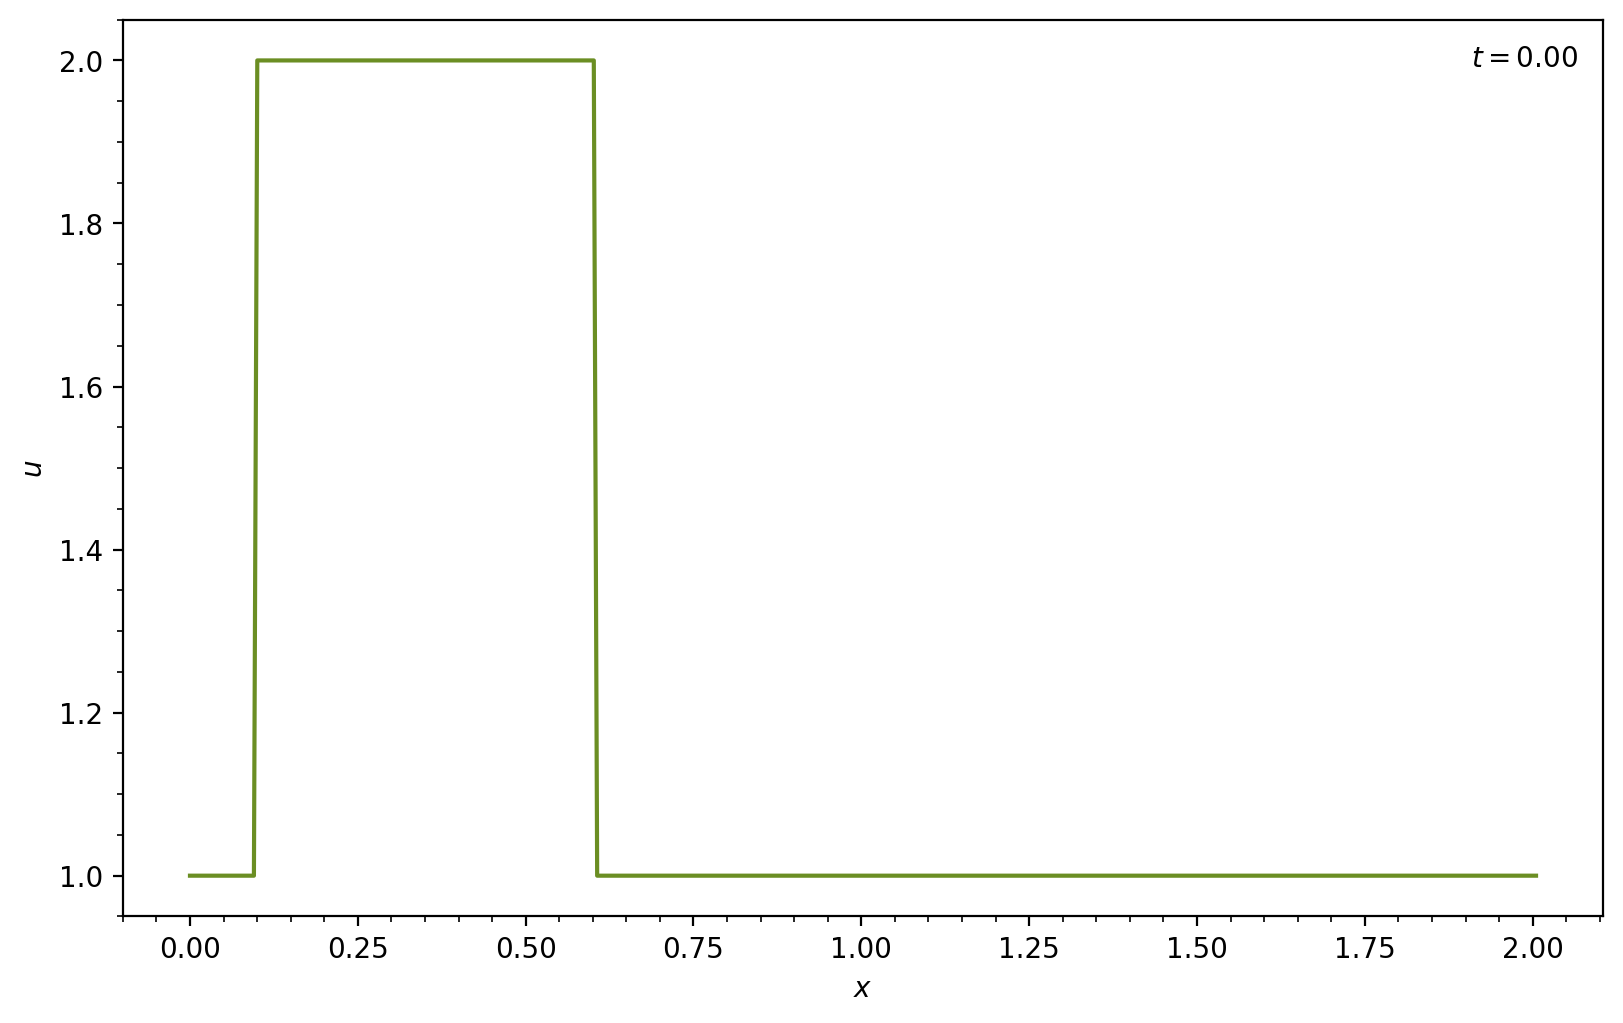

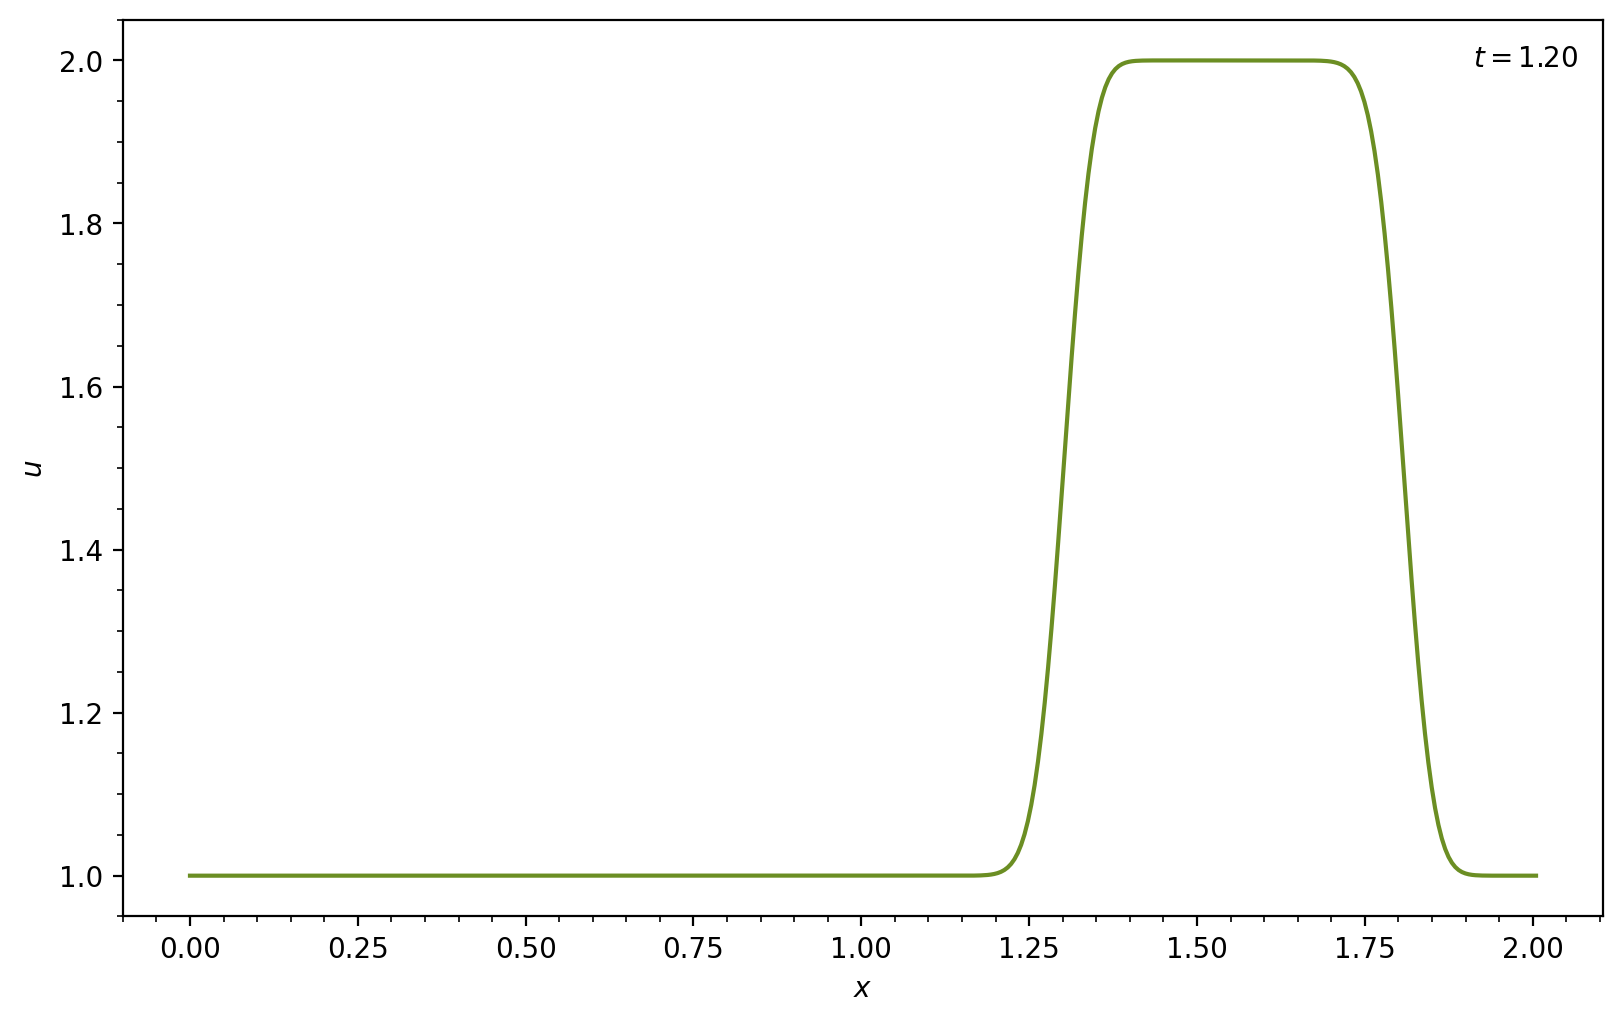

In [2]:
# Setup

nx = 401
dx = 2 / (nx - 1)

x = np.linspace(0, nx * dx, nx)

nt = 300
dt = .004

c = 1.

C = c * dt / dx

print(f'\nC = {C:.2f}\n')

u = np.ones(nx)
u[int(.1 / dx):int(.6 / dx + 1)] = 2.

# Initial

plt.plot(x, u)
plt.plot([], [], ' ', label=f'$t = ${0.:.2f}')
plt.xlabel(r'$x$')
plt.ylabel(r'$u$')
plt.legend(loc='upper right')
ylim = plt.ylim()
xlim = plt.xlim()
plt.show()
plt.close()

# Evolution

k = 5

history = [u.copy()]

for n in range(nt):
    u[1:] = u[1:] - C * (u[1:] - u [:-1])

    if n % k == 0:
        history.append(u.copy())
        
# Final

plt.plot(x, u)
plt.plot([], [], ' ', label=f'$t = ${nt * dt:.2f}')
plt.xlabel(r'$x$')
plt.ylabel(r'$u$')
plt.legend(loc='upper right')
plt.xlim(xlim)
plt.ylim(ylim)
plt.show()
plt.close()

# Animation

pause_number = 20
padded_history = ([history[0]] * pause_number) + history + ([history[-1]] * pause_number)

fig, ax = plt.subplots(dpi=150)
line, = ax.plot(x, padded_history[0])
ax.plot([], [], ' ', label=f'$t = ${0.:.2f}')
leg = ax.legend(loc='upper right')
ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.set_xlabel(r'$x$')
ax.set_ylabel(r'$u$')

def update(frame):
    line.set_ydata(padded_history[frame])
    display_frame = max(0, min(frame - pause_number, len(history) - 1))
    time = display_frame * k * dt
    leg.get_texts()[0].set_text(f'$t = ${time:.2f}')
    return line, leg

ani = FuncAnimation(fig, update, frames=len(padded_history), interval=50, blit=True)

ani.save("1d_lin_conv_adv.gif", writer=PillowWriter(fps=20))

plt.close()
HTML('<img src="1d_lin_conv_adv.gif" width="800">')

### 1D Nonlinear Convection / Advection

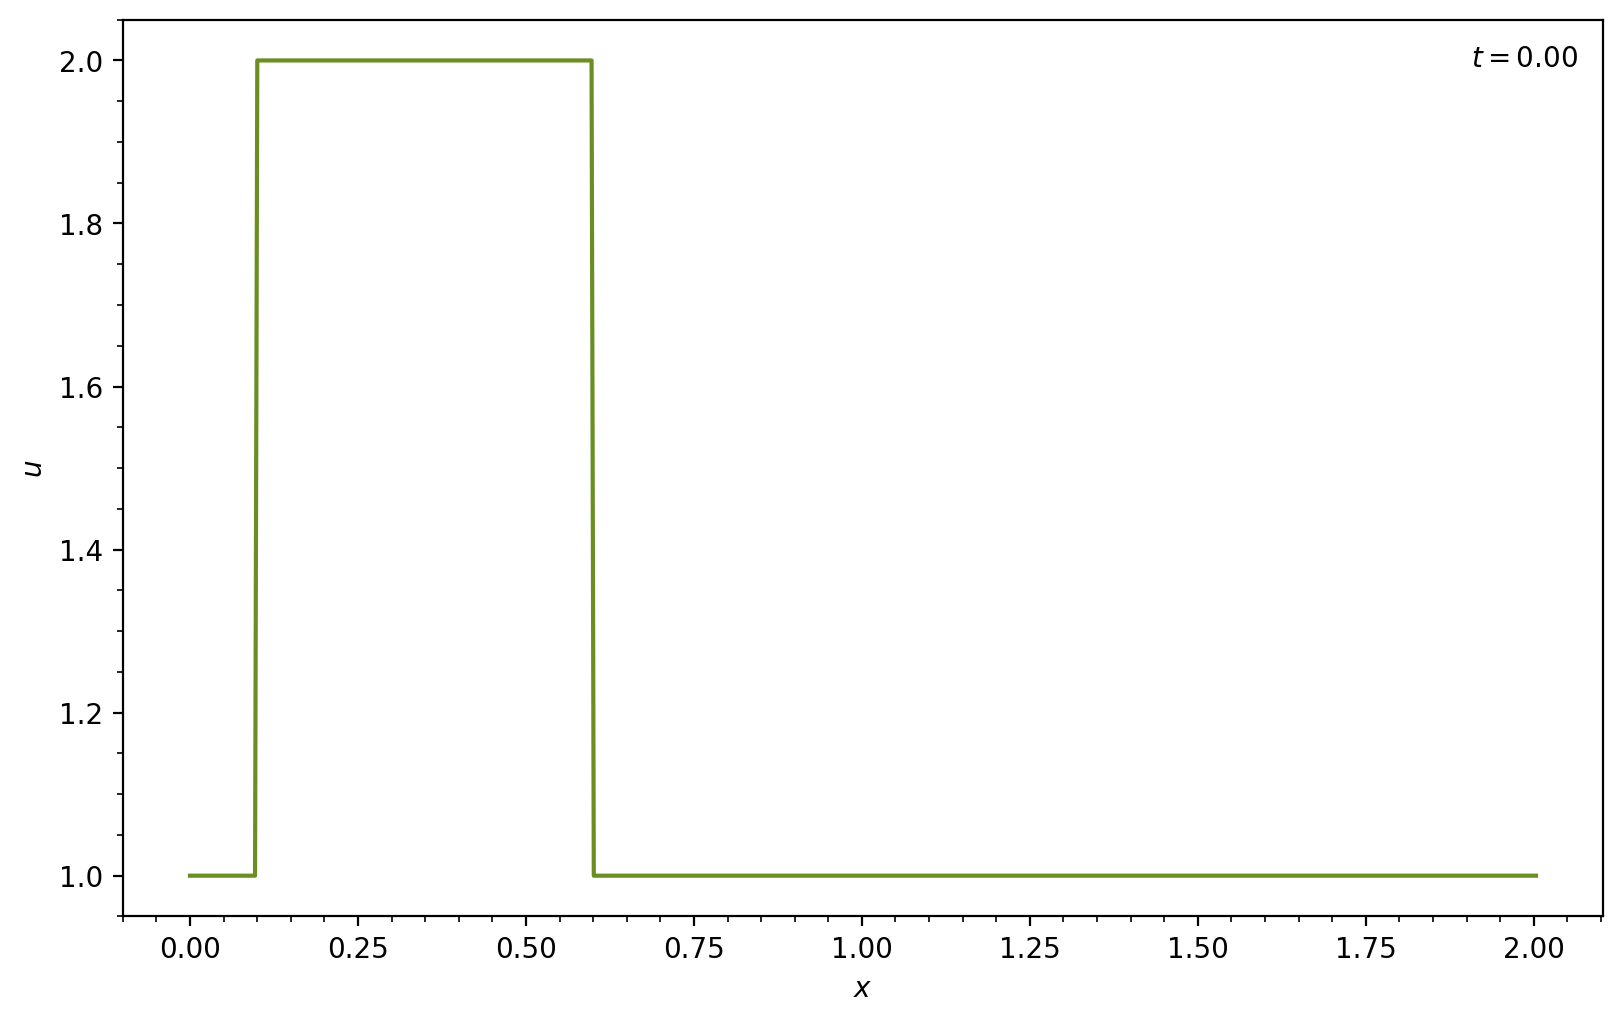

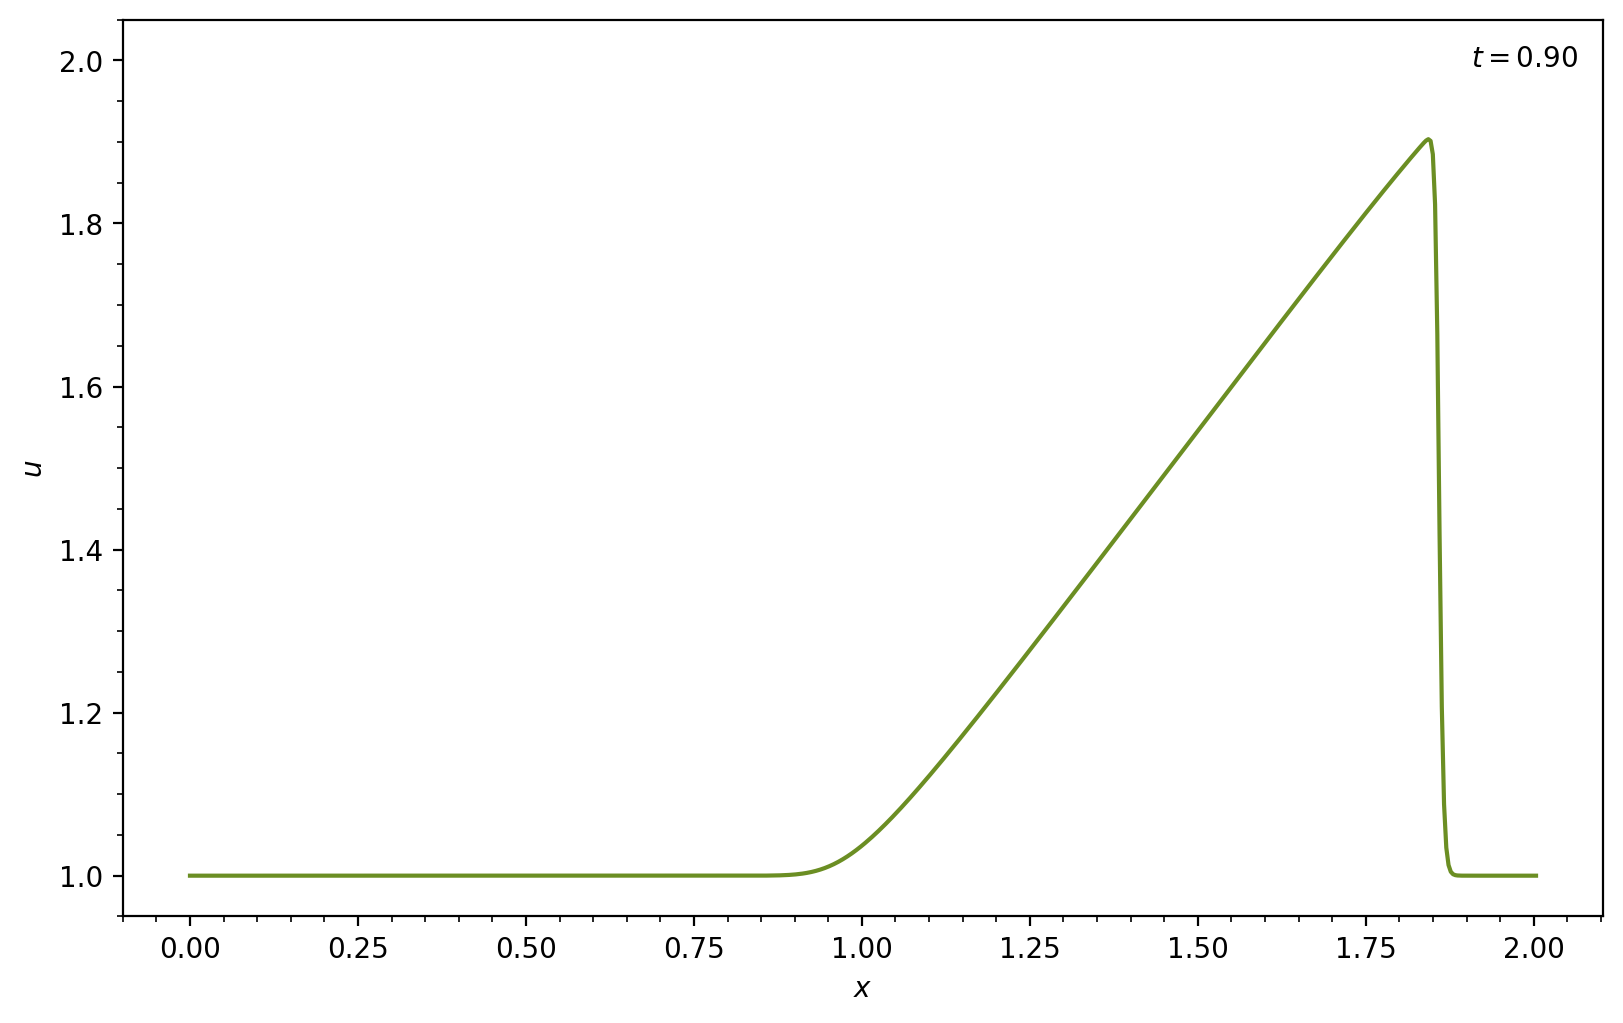

In [3]:
# Setup

nx = 601
dx = 2 / (nx - 1)

x = np.linspace(0, nx * dx, nx)

nt = 900
dt = .001

u = np.ones(nx)
u[int(.1 / dx):int(.6 / dx + 1)] = 2.

# Initial

plt.plot(x, u)
plt.plot([], [], ' ', label=f'$t = ${0.:.2f}')
plt.xlabel(r'$x$')
plt.ylabel(r'$u$')
plt.legend(loc='upper right')
ylim = plt.ylim()
xlim = plt.xlim()
plt.show()
plt.close()

# Evolution

k = 15

history = [u.copy()]

for n in range(nt):
    u[1:] = u[1:] - u[1:] * dt / dx * (u[1:] - u [:-1])

    if n % k == 0:
        history.append(u.copy())
        
# Final

plt.plot(x, u)
plt.plot([], [], ' ', label=f'$t = ${nt * dt:.2f}')
plt.xlabel(r'$x$')
plt.ylabel(r'$u$')
plt.legend(loc='upper right')
plt.xlim(xlim)
plt.ylim(ylim)
plt.show()
plt.close()

# Animation

pause_number = 20
padded_history = ([history[0]] * pause_number) + history + ([history[-1]] * pause_number)

fig, ax = plt.subplots(dpi=150)
line, = ax.plot(x, padded_history[0])
ax.plot([], [], ' ', label=f'$t = ${0.:.2f}')
leg = ax.legend(loc='upper right')
ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.set_xlabel(r'$x$')
ax.set_ylabel(r'$u$')

def update(frame):
    line.set_ydata(padded_history[frame])
    display_frame = max(0, min(frame - pause_number, len(history) - 1))
    time = display_frame * k * dt
    leg.get_texts()[0].set_text(f'$t = ${time:.2f}')
    return line, leg

ani = FuncAnimation(fig, update, frames=len(padded_history), interval=50, blit=True)

ani.save("1d_nonlin_conv_adv.gif", writer=PillowWriter(fps=20))

plt.close()
HTML('<img src="1d_nonlin_conv_adv.gif" width="800">')

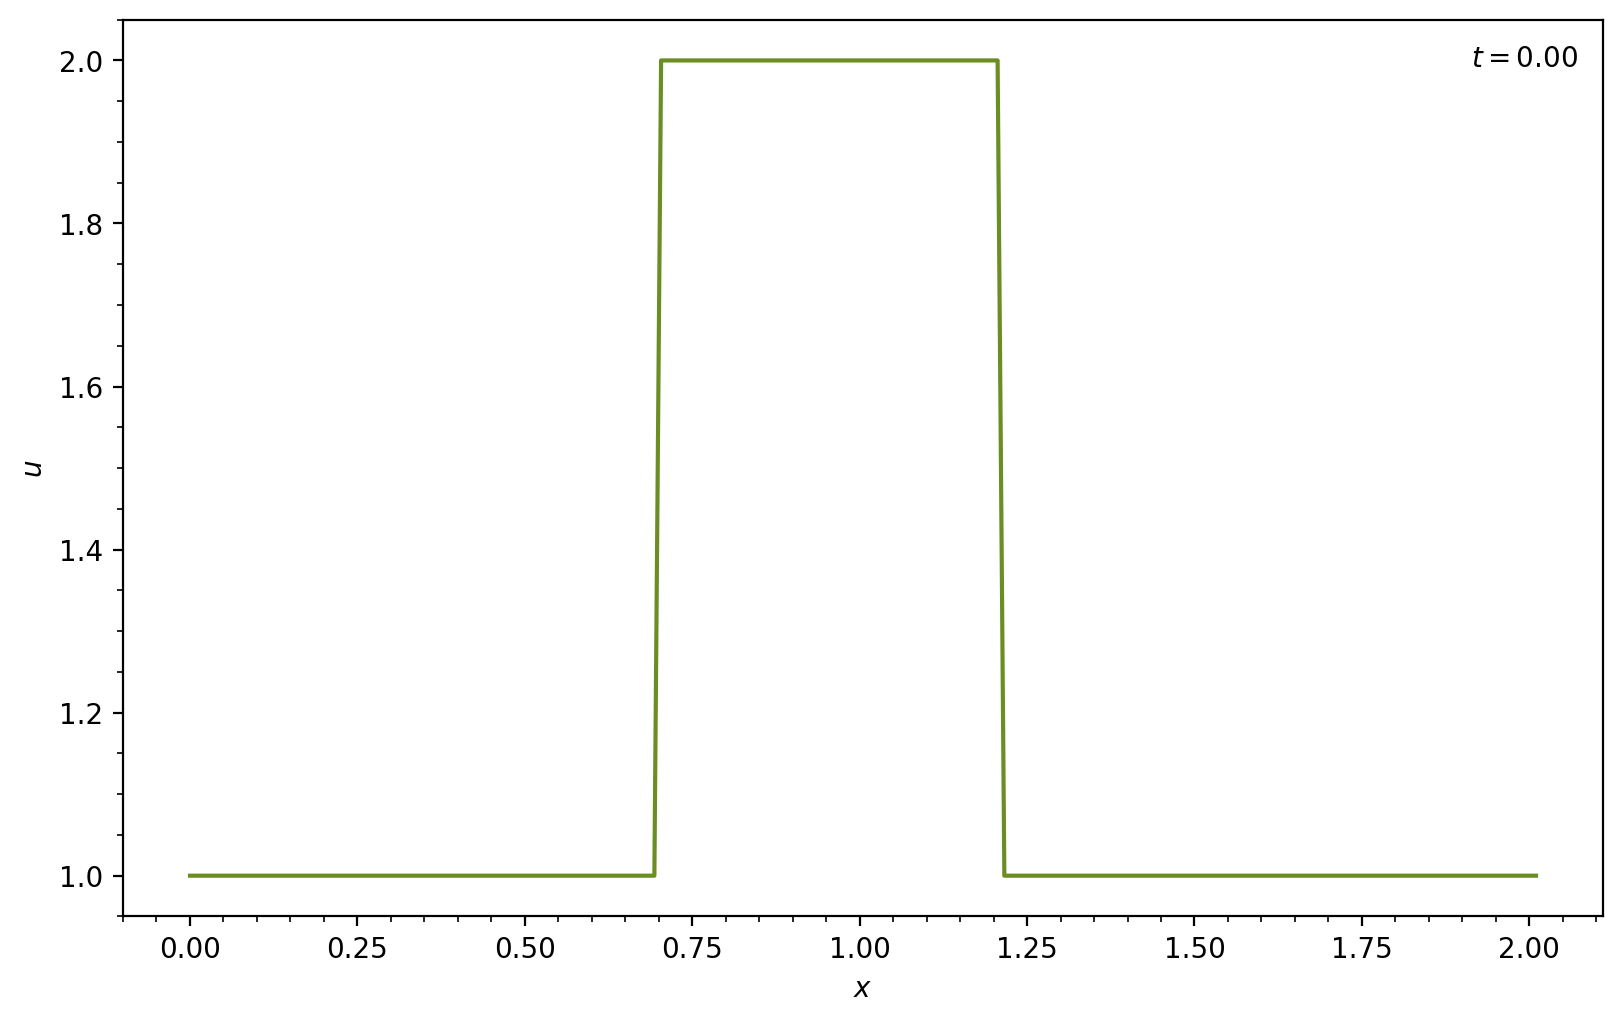

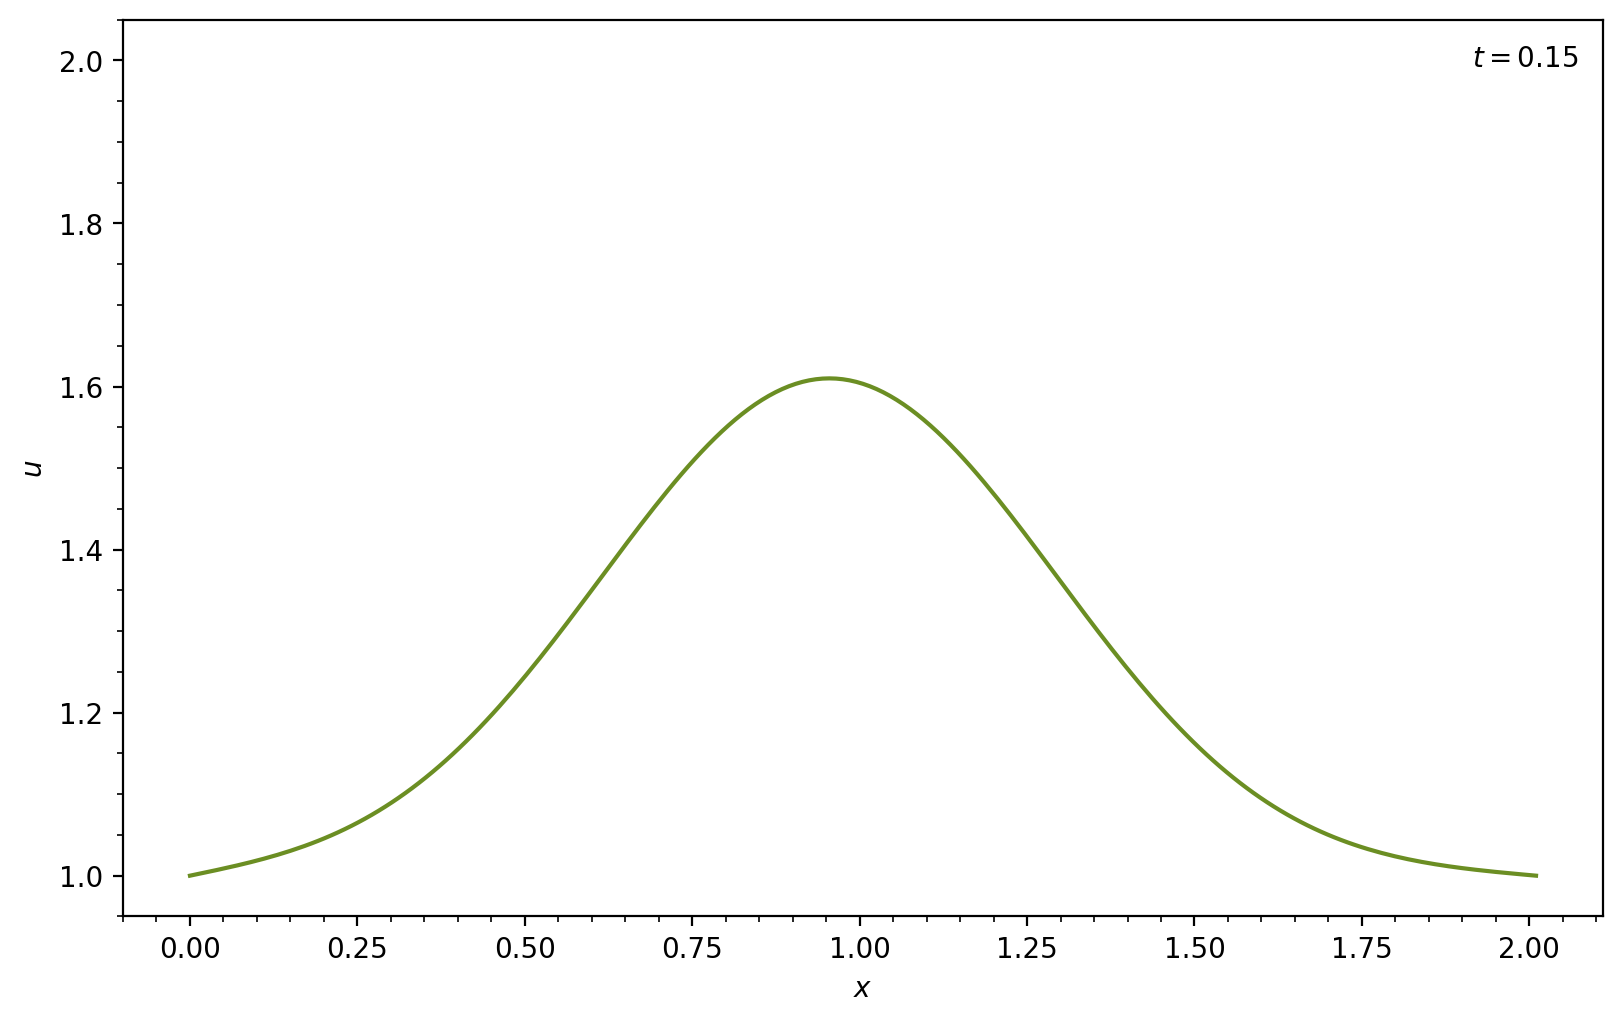

In [4]:
# Setup

nx = 201
dx = 2 / (nx - 1)

x = np.linspace(0, nx * dx, nx)

nt = 2200

nu = .3
sigma = .2

dt = sigma * dx**2 / nu

u = np.ones(nx)
u[int(.7 / dx):int(1.2 / dx + 1)] = 2.

# Initial

plt.plot(x, u)
plt.plot([], [], ' ', label=f'$t = ${0.:.2f}')
plt.xlabel(r'$x$')
plt.ylabel(r'$u$')
plt.legend(loc='upper right')
ylim = plt.ylim()
xlim = plt.xlim()
plt.show()
plt.close()

# Evolution

k = 40

history = [u.copy()]

for n in range(nt):
    u[1:-1] = u[1:-1] + nu * dt / dx**2 * (u[2:] - 2 * u[1:-1] + u[:-2])

    if n % k == 0:
        history.append(u.copy())
        
# Final

plt.plot(x, u)
plt.plot([], [], ' ', label=f'$t = ${nt * dt:.2f}')
plt.xlabel(r'$x$')
plt.ylabel(r'$u$')
plt.legend(loc='upper right')
plt.xlim(xlim)
plt.ylim(ylim)
plt.show()
plt.close()

# Animation

pause_number = 20
padded_history = ([history[0]] * pause_number) + history + ([history[-1]] * pause_number)

fig, ax = plt.subplots(dpi=150)
line, = ax.plot(x, padded_history[0])
ax.plot([], [], ' ', label=f'$t = ${0.:.2f}')
leg = ax.legend(loc='upper right')
ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.set_xlabel(r'$x$')
ax.set_ylabel(r'$u$')

def update(frame):
    line.set_ydata(padded_history[frame])
    display_frame = max(0, min(frame - pause_number, len(history) - 1))
    time = display_frame * k * dt
    leg.get_texts()[0].set_text(f'$t = ${time:.2f}')
    return line, leg

ani = FuncAnimation(fig, update, frames=len(padded_history), interval=50, blit=True)

ani.save("1d_diffus.gif", writer=PillowWriter(fps=20))

plt.close()
HTML('<img src="1d_diffus.gif" width="800">')

### 1D Bateman-Burgers Equation

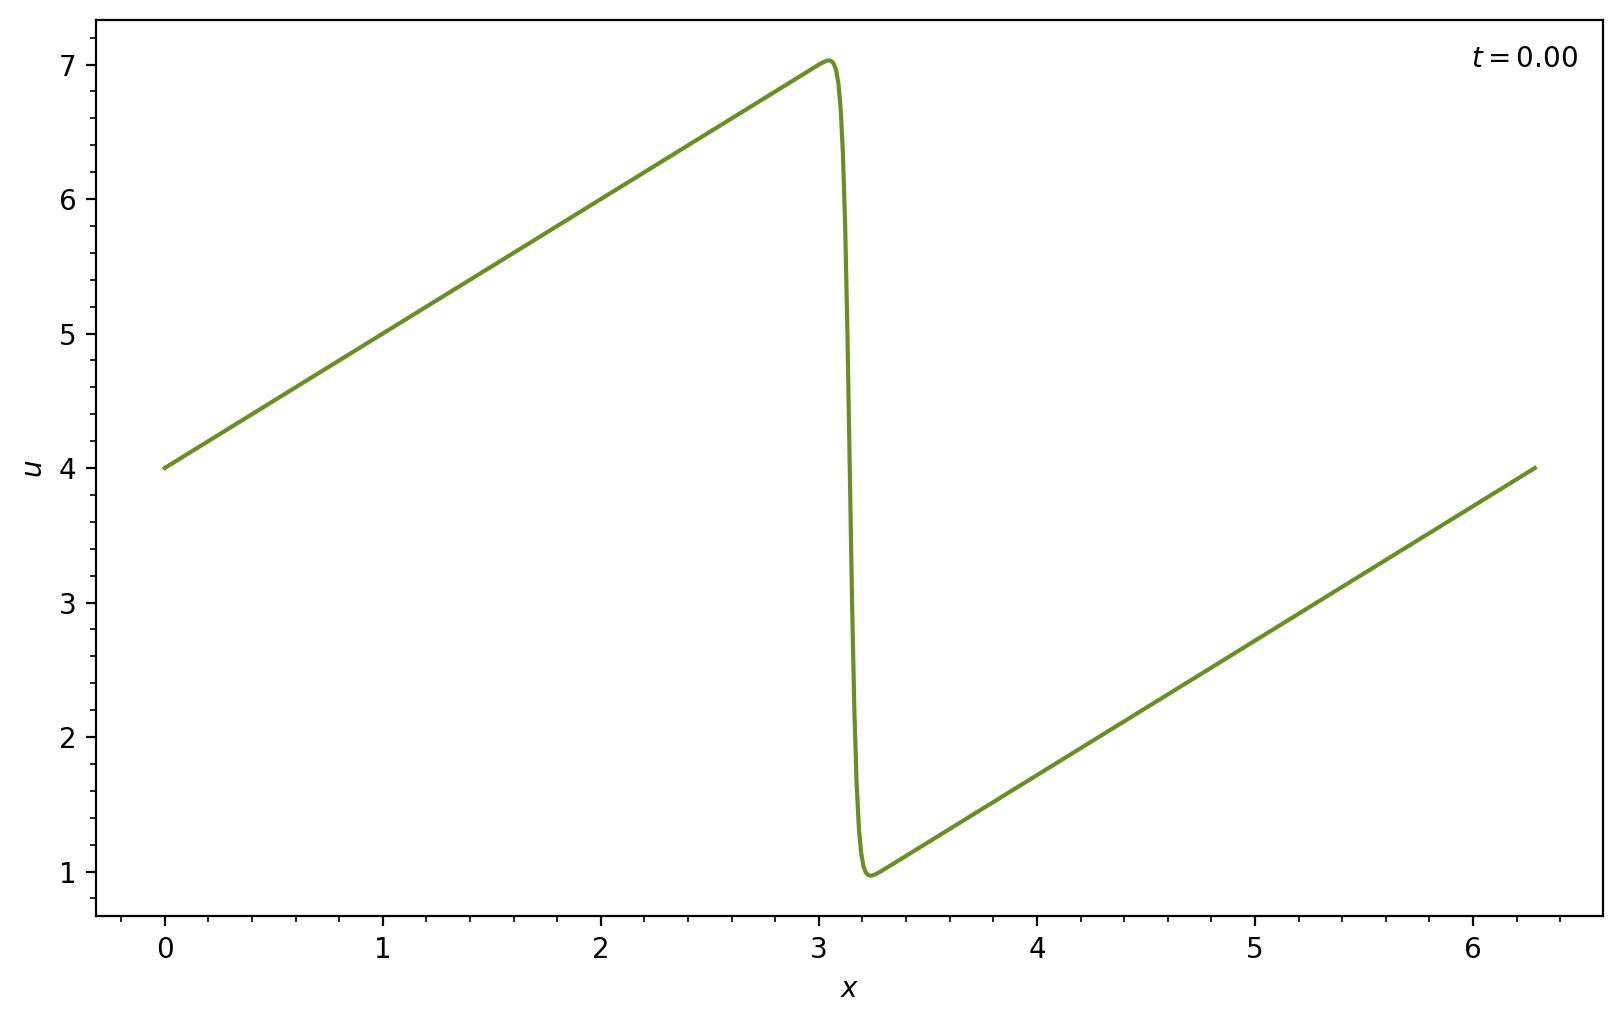

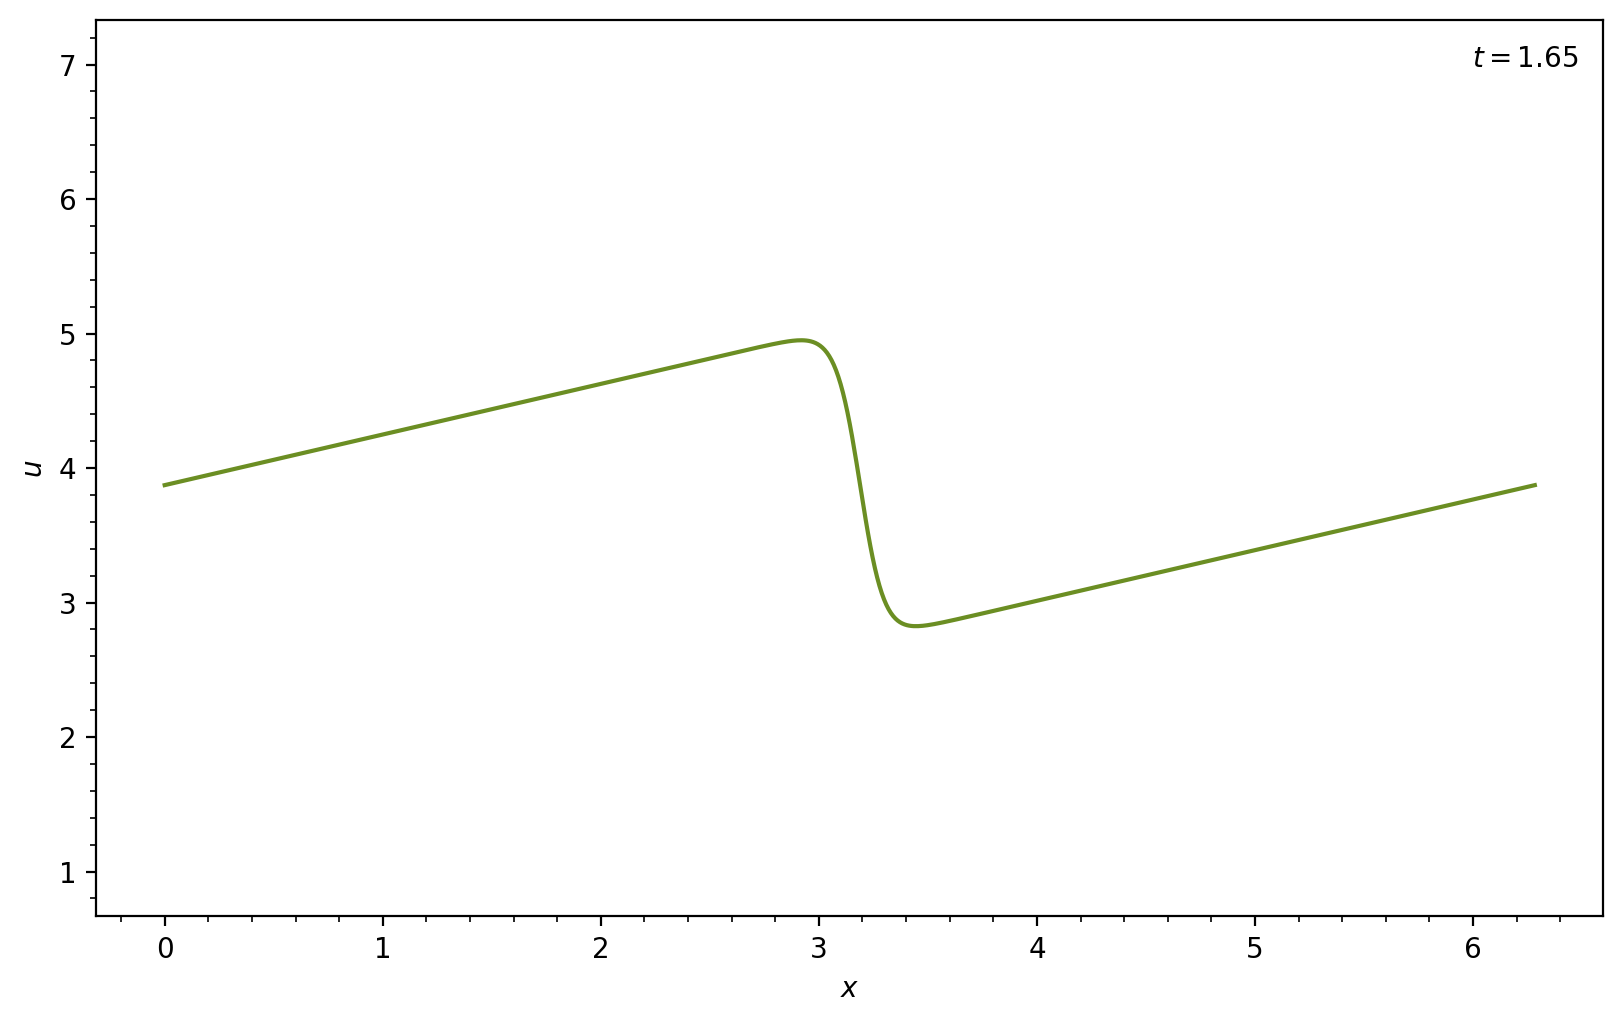

In [5]:
# Computation

x, nu, t = sym.symbols('x nu t')

phi = (sym.exp(-(x - 4 * t)**2 / (4 * nu * (t + 1))) +
       sym.exp(-(x - 4 * t - 2 * sym.pi)**2 / (4 * nu * (t + 1))))

phiprime = phi.diff(x)

u = -2 * nu * (phiprime / phi) + 4

ufunc = lambdify((t, x, nu), u)

# Setup

nx = 601
nt = 3160
dx = 2 * np.pi / (nx - 1)
nu = .05
dt = dx * nu

x = np.linspace(0, 2 * np.pi, nx)

un = np.empty(nx)

u = np.asarray([ufunc(0, x0, nu) for x0 in x])

# Initial

plt.plot(x, u)
plt.plot([], [], ' ', label=f'$t = ${0.:.2f}')
plt.xlabel(r'$x$')
plt.ylabel(r'$u$')
plt.legend(loc='upper right')
ylim = plt.ylim()
xlim = plt.xlim()
plt.show()
plt.close()

# Evolution

k = 20

history = [u.copy()]

for n in range(nt):
    un = u.copy()
    u[1:-1] = un[1:-1] - un[1:-1] * dt / dx * (un[1:-1] - un[:-2]) + nu * dt / dx**2 * (un[2:] - 2 * un[1:-1] + un[:-2])
    u[0] = un[0] - un[0] * dt / dx * (un[0] - un[-2]) + nu * dt / dx**2 * (un[1] - 2 * un[0] + un[-2])
    u[-1] = u[0]

    if n % k == 0:
        history.append(u.copy())
        
# Final

plt.plot(x, u)
plt.plot([], [], ' ', label=f'$t = ${nt * dt:.2f}')
plt.xlabel(r'$x$')
plt.ylabel(r'$u$')
plt.legend(loc='upper right')
plt.xlim(xlim)
plt.ylim(ylim)
plt.show()
plt.close()

# Animation

pause_number = 20
padded_history = ([history[0]] * pause_number) + history + ([history[-1]] * pause_number)

fig, ax = plt.subplots(dpi=150)
line, = ax.plot(x, padded_history[0])
ax.plot([], [], ' ', label=f'$t = ${0.:.2f}')
leg = ax.legend(loc='upper right')
ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.set_xlabel(r'$x$')
ax.set_ylabel(r'$u$')

def update(frame):
    line.set_ydata(padded_history[frame])
    display_frame = max(0, min(frame - pause_number, len(history) - 1))
    time = display_frame * k * dt
    leg.get_texts()[0].set_text(f'$t = ${time:.2f}')
    return line, leg

ani = FuncAnimation(fig, update, frames=len(padded_history), interval=50, blit=True)

ani.save("1d_bate_burg_eq.gif", writer=PillowWriter(fps=20))

plt.close()
HTML('<img src="1d_bate_burg_eq.gif" width="800">')

### 2D Linear Convection / Advection

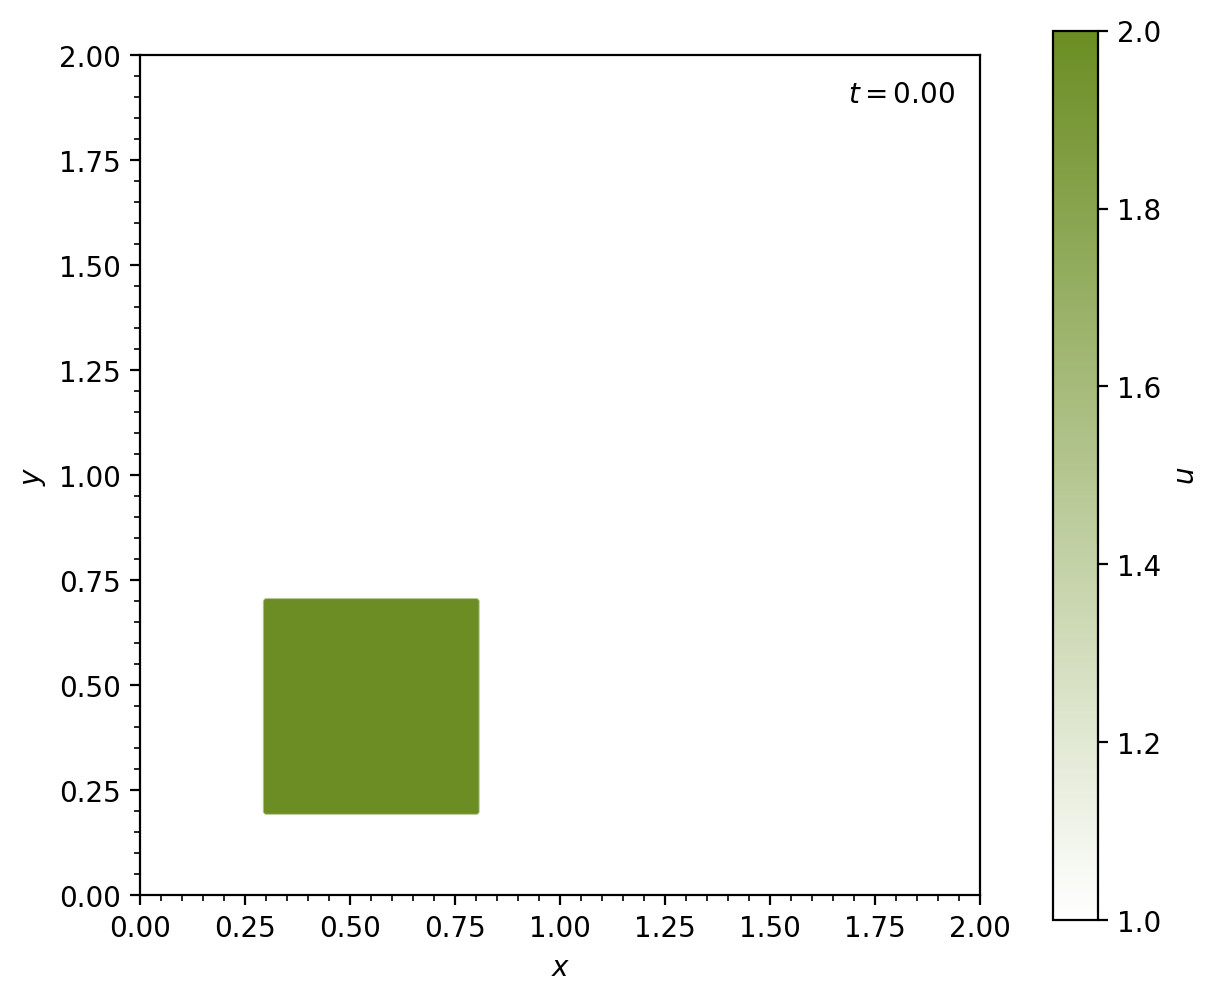

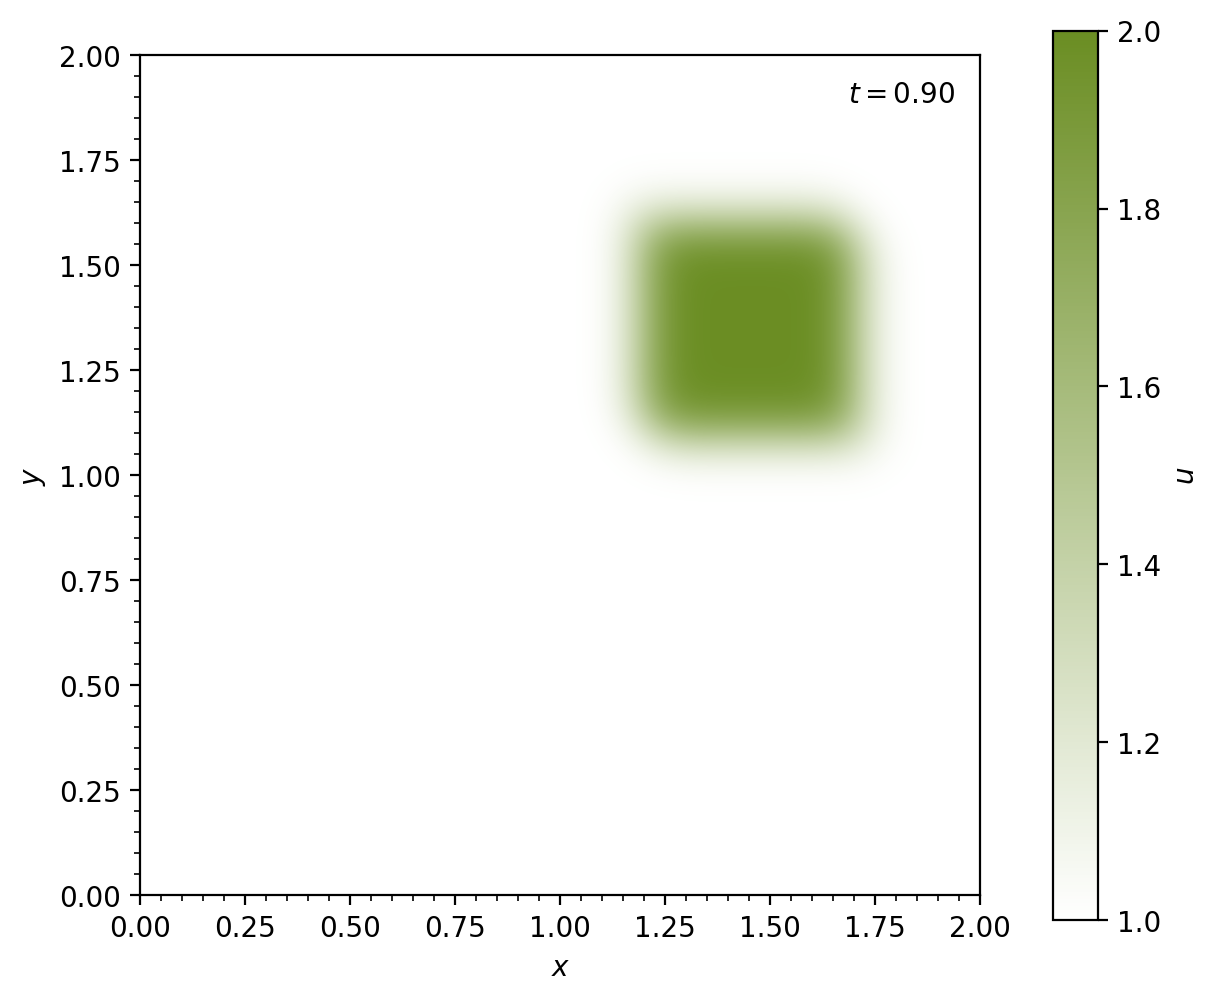

In [6]:
# Adjustment

plt.rcParams['figure.figsize'] = [6,5]

# Setup

nx = 401
ny = 401
nt = 900
c = 1
dx = 2 / (nx - 1)
dy = 2 / (ny - 1)
sigma = .2
dt = sigma * dx

x = np.linspace(0, 2, nx)
y = np.linspace(0, 2, ny)

X, Y = np.meshgrid(x, y)                            

u = np.ones((ny, nx))

u[int(.2 / dy):int(.7 / dy + 1),int(.3 / dx):int(.8 / dx + 1)] = 2.

# Initial

plt.plot([], [], ' ', label=f'$t = ${0.:.2f}')
cnt = plt.contourf(X, Y, u[:], levels=np.linspace(1, 2, 256), cmap=OliveDrab_r)
cnt.set_edgecolor('face')
cb = plt.colorbar(cnt, ticks=np.linspace(1, 2, 6), location='right')
cb.set_label(r'$u$')
plt.xlabel(r'$x$')
plt.ylabel(r'$y$')
plt.legend(loc='upper right')
plt.gca().set_aspect('equal', 'box')
plt.show()
plt.close()

# Evolution

k = 20

history = [u.copy()]

for n in range(nt):
    u[1:, 1:] = (u[1:, 1:] - (c * dt / dx * (u[1:, 1:] - u[1:, :-1])) - (c * dt / dy * (u[1:, 1:] - u[:-1, 1:])))

    if n % k == 0:
        history.append(u.copy())

# Final

plt.plot([], [], ' ', label=f'$t = ${nt * dt:.2f}')
cnt = plt.contourf(X, Y, u[:], levels=np.linspace(1, 2, 256), cmap=OliveDrab_r)
cnt.set_edgecolor('face')
cb = plt.colorbar(cnt, ticks=np.linspace(1, 2, 6), location='right')
cb.set_label(r'$u$')
plt.xlabel(r'$x$')
plt.ylabel(r'$y$')
plt.legend(loc='upper right')
plt.gca().set_aspect('equal', 'box')
plt.show()
plt.close()

# Animation

pause_number = 20
padded_history = ([history[0]] * pause_number) + history + ([history[-1]] * pause_number)

fig, ax = plt.subplots(dpi=150)
ax.plot([], [], ' ', label=f'$t = ${0.:.2f}')
leg = ax.legend(loc='upper right')
cnt = ax.contourf(X, Y, padded_history[0], levels=np.linspace(1, 2, 256), cmap=OliveDrab_r)
cnt.set_edgecolor('face')
cb = plt.colorbar(cnt, ticks=np.linspace(1, 2, 6), location='right')
cb.set_label(r'$u$')
plt.xlabel(r'$x$')
plt.ylabel(r'$y$')
ax.set_aspect('equal', 'box')

def update(frame):
    global cnt

    if cnt is not None:
        cnt.remove()
    
    cnt = ax.contourf(X, Y, padded_history[frame], levels=np.linspace(1, 2, 256), cmap=OliveDrab_r)
    display_frame = max(0, min(frame - pause_number, len(history) - 1))
    time = display_frame * k * dt
    leg.get_texts()[0].set_text(f'$t = ${time:.2f}')
    return []

ani = FuncAnimation(fig, update, frames=len(padded_history), interval=50, blit=False)

ani.save("2d_lin_conv_adv.gif", writer=PillowWriter(fps=20))

plt.close()
HTML('<img src="2d_lin_conv_adv.gif" width="600">')

### 2D Nonlinear Convection / Advection

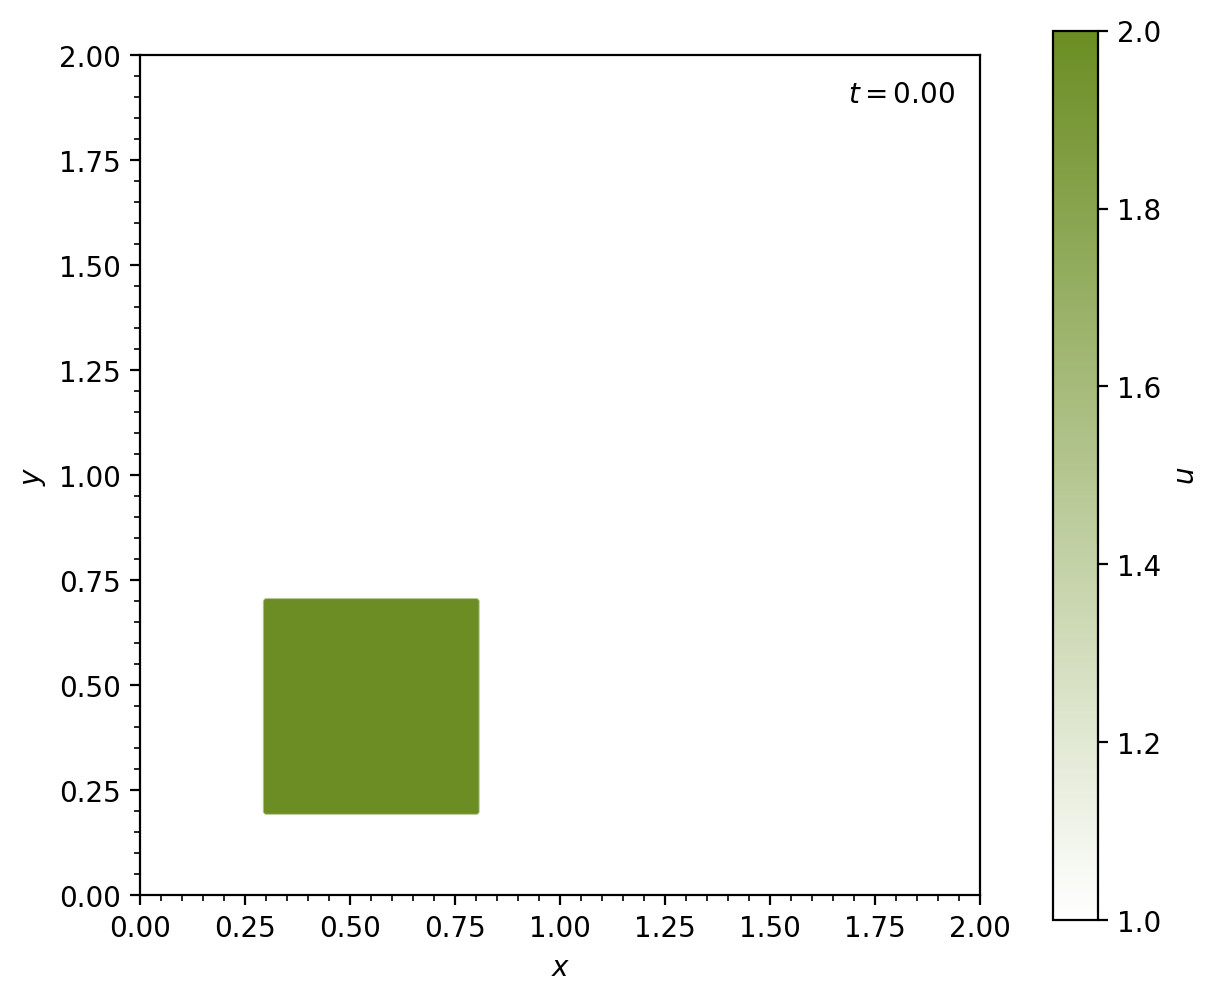

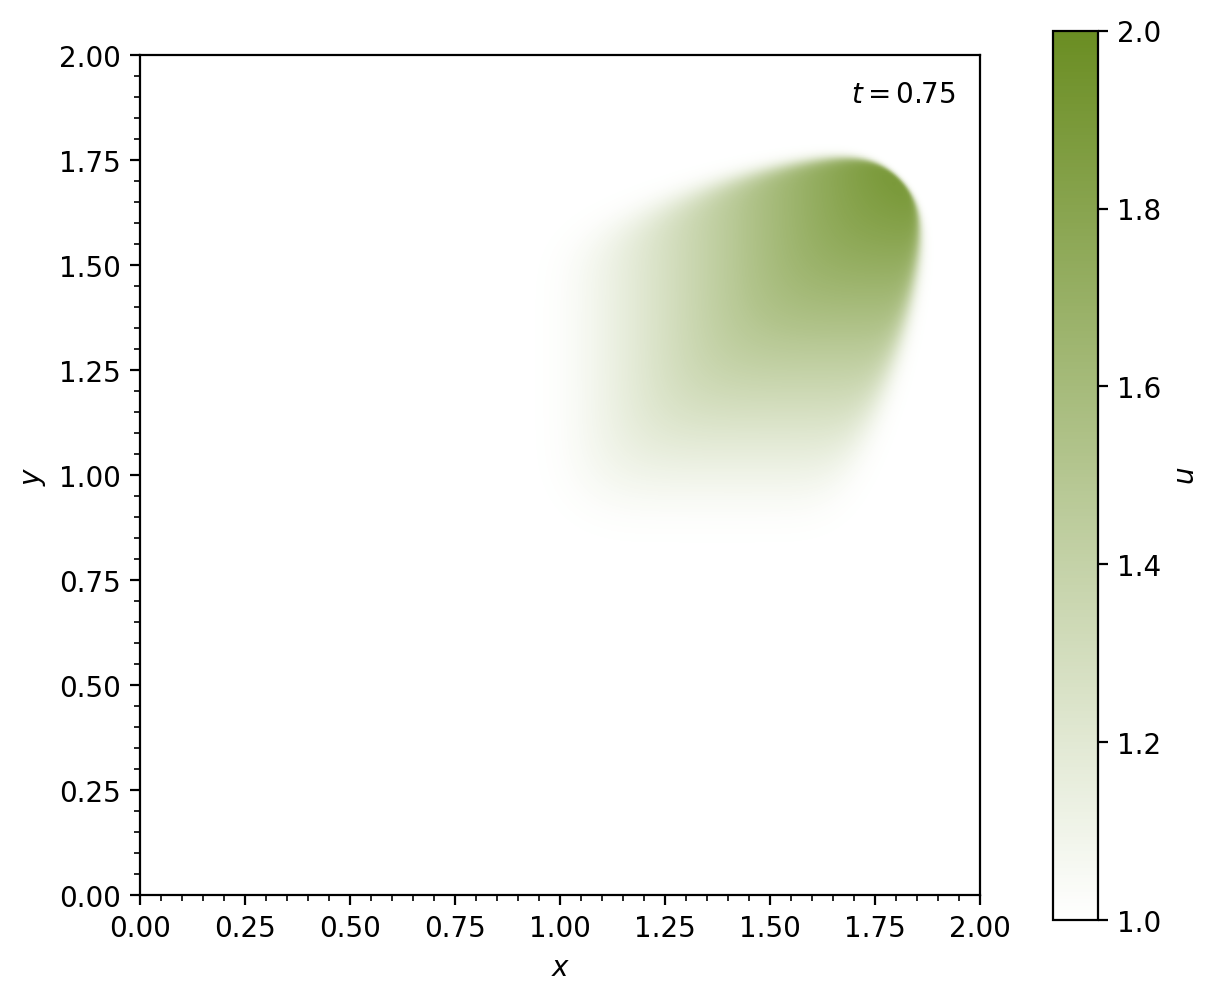

In [7]:
# Setup

nx = 401
ny = 401
nt = 750
dx = 2 / (nx - 1)
dy = 2 / (ny - 1)
sigma = .2
dt = sigma * dx

x = np.linspace(0, 2, nx)
y = np.linspace(0, 2, ny)

X, Y = np.meshgrid(x, y)                            

u = np.ones((ny, nx))
v = np.ones((ny, nx))

un = np.ones((ny, nx))
vn = np.ones((ny, nx))

u[int(.2 / dy):int(.7 / dy + 1),int(.3 / dx):int(.8 / dx + 1)] = 2.
v[int(.2 / dy):int(.7 / dy + 1), int(.3 / dx):int(.8 / dx + 1)] = 2.

# Initial

plt.plot([], [], ' ', label=f'$t = ${0.:.2f}')
cnt = plt.contourf(X, Y, u[:], levels=np.linspace(1, 2, 256), cmap=OliveDrab_r)
cnt.set_edgecolor('face')
cb = plt.colorbar(cnt, ticks=np.linspace(1, 2, 6), location='right')
cb.set_label(r'$u$')
plt.xlabel(r'$x$')
plt.ylabel(r'$y$')
plt.legend(loc='upper right')
plt.gca().set_aspect('equal', 'box')
plt.show()
plt.close()

# Evolution

k = 15

history = [u.copy()]

for n in range(nt):
    un = u.copy()
    vn = v.copy()

    u[1:, 1:] = (un[1:, 1:] - (un[1:, 1:] * c * dt / dx * (un[1:, 1:] - un[1:, :-1])) - 
                 vn[1:, 1:] * c * dt / dy * (un[1:, 1:] - un[:-1, 1:]))
    v[1:, 1:] = (vn[1:, 1:] - (un[1:, 1:] * c * dt / dx * (vn[1:, 1:] - vn[1:, :-1])) -
                 vn[1:, 1:] * c * dt / dy * (vn[1:, 1:] - vn[:-1, 1:]))
    
    u[0, :] = 1
    u[-1, :] = 1
    u[:, 0] = 1
    u[:, -1] = 1
    
    v[0, :] = 1
    v[-1, :] = 1
    v[:, 0] = 1
    v[:, -1] = 1

    if n % k == 0:
        history.append(u.copy())

# Final
                 
plt.plot([], [], ' ', label=f'$t = ${nt * dt:.2f}')
cnt = plt.contourf(X, Y, u[:], levels=np.linspace(1, 2, 256), cmap=OliveDrab_r)
cnt.set_edgecolor('face')
cb = plt.colorbar(cnt, ticks=np.linspace(1, 2, 6), location='right')
cb.set_label(r'$u$')
plt.xlabel(r'$x$')
plt.ylabel(r'$y$')
plt.legend()
plt.gca().set_aspect('equal', 'box')
plt.show()
plt.close()

# Animation

pause_number = 20
padded_history = ([history[0]] * pause_number) + history + ([history[-1]] * pause_number)

fig, ax = plt.subplots(dpi=150)
ax.plot([], [], ' ', label=f'$t = ${0.:.2f}')
leg = ax.legend(loc='upper right')
cnt = ax.contourf(X, Y, padded_history[0], levels=np.linspace(1, 2, 256), cmap=OliveDrab_r)
cnt.set_edgecolor('face')
cb = plt.colorbar(cnt, ticks=np.linspace(1, 2, 6), location='right')
cb.set_label(r'$u$')
plt.xlabel(r'$x$')
plt.ylabel(r'$y$')
ax.set_aspect('equal', 'box')

def update(frame):
    global cnt

    if cnt is not None:
        cnt.remove()
    
    cnt = ax.contourf(X, Y, padded_history[frame], levels=np.linspace(1, 2, 256), cmap=OliveDrab_r)
    display_frame = max(0, min(frame - pause_number, len(history) - 1))
    time = display_frame * k * dt
    leg.get_texts()[0].set_text(f'$t = ${time:.2f}')
    return []

ani = FuncAnimation(fig, update, frames=len(padded_history), interval=50, blit=False)

ani.save("2d_nonlin_conv_adv.gif", writer=PillowWriter(fps=20))

plt.close()
HTML('<img src="2d_nonlin_conv_adv.gif" width="600">')

### 2D Diffusion

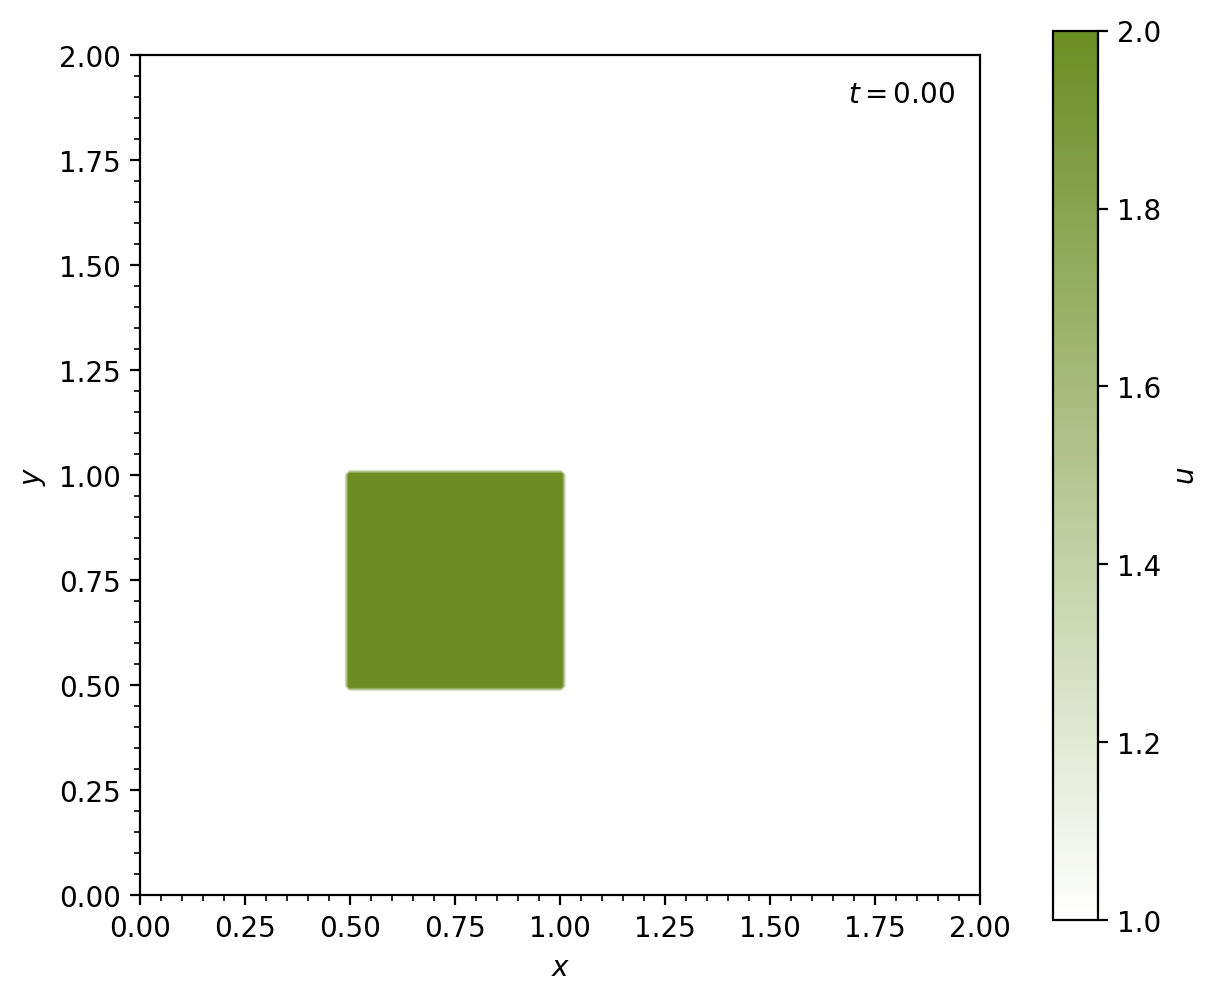

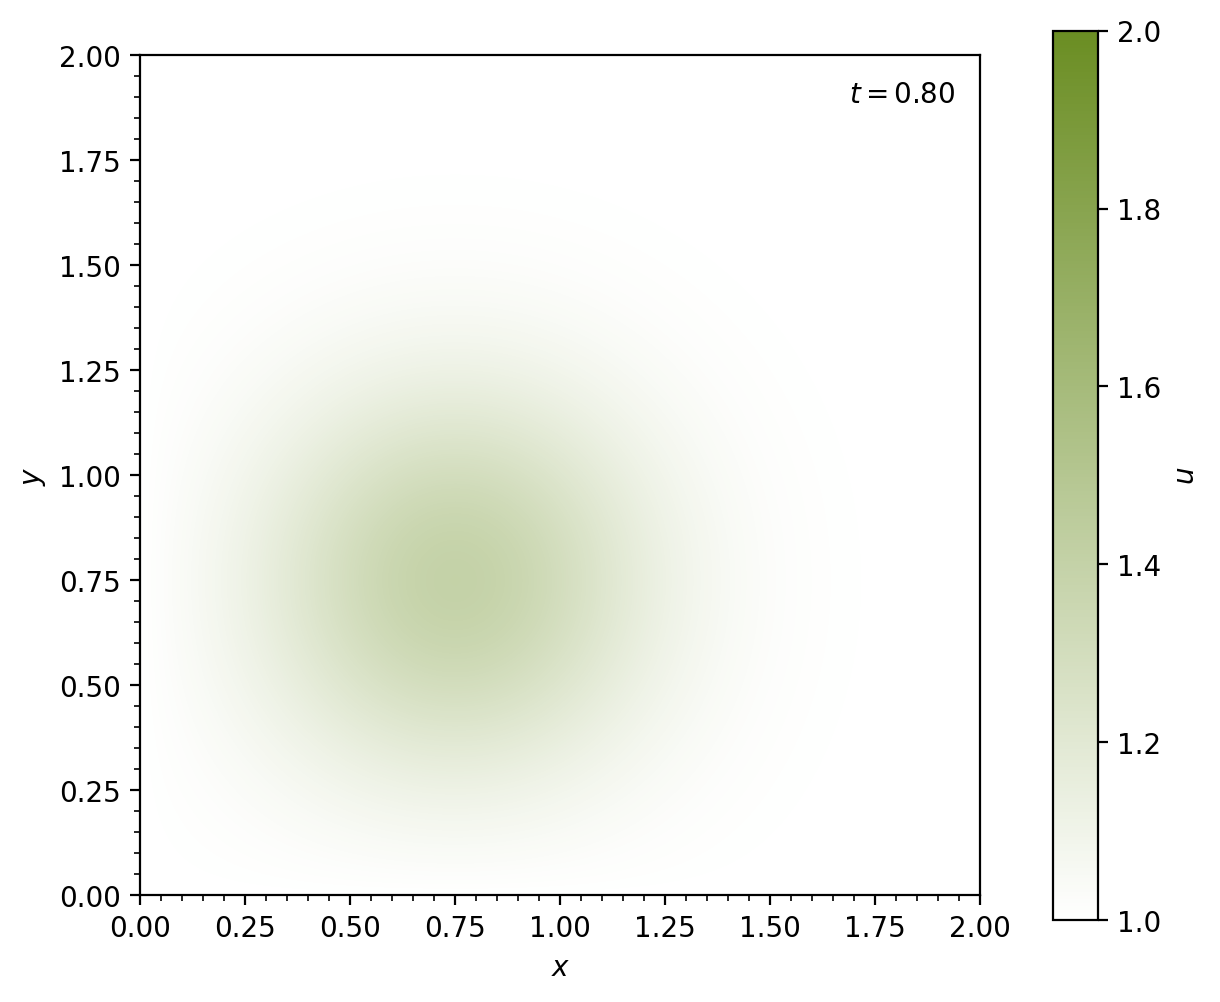

In [8]:
# Setup

nx = 201
ny = 201
nt = 1600
dx = 2 / (nx - 1)
dy = 2 / (ny - 1)
nu = .05
sigma = .25
dt = sigma * dx * dy / nu

x = np.linspace(0, 2, nx)
y = np.linspace(0, 2, ny)

X, Y = np.meshgrid(x, y)                            

u = np.ones((ny, nx))

un = np.ones((ny, nx))

u[int(.5 / dy):int(1. / dy + 1),int(.5 / dx):int(1. / dx + 1)] = 2.

# Initial

plt.plot([], [], ' ', label=f'$t = ${0.:.2f}')
cnt = plt.contourf(X, Y, u[:], levels=np.linspace(1, 2, 256), cmap=OliveDrab_r)
cnt.set_edgecolor('face')
cb = plt.colorbar(cnt, ticks=np.linspace(1, 2, 6), location='right')
cb.set_label(r'$u$')
plt.xlabel(r'$x$')
plt.ylabel(r'$y$')
plt.legend(loc='upper right')
plt.gca().set_aspect('equal', 'box')
plt.show()
plt.close()

# Evolution

k = 25

history = [u.copy()]

for n in range(nt):
    un = u.copy()
    u[1:-1, 1:-1] = (un[1:-1,1:-1] + nu * dt / dx**2 * (un[1:-1, 2:] - 2 * un[1:-1, 1:-1] + un[1:-1, 0:-2]) +
                         nu * dt / dy**2 * (un[2:,1: -1] - 2 * un[1:-1, 1:-1] + un[0:-2, 1:-1]))

    u[0, :] = 1
    u[-1, :] = 1
    u[:, 0] = 1
    u[:, -1] = 1

    if n % k == 0:
        history.append(u.copy())

# Final
                 
plt.plot([], [], ' ', label=f'$t = ${nt * dt:.2f}')
cnt = plt.contourf(X, Y, u[:], levels=np.linspace(1, 2, 256), cmap=OliveDrab_r)
cnt.set_edgecolor('face')
cb = plt.colorbar(cnt, ticks=np.linspace(1, 2, 6), location='right')
cb.set_label(r'$u$')
plt.xlabel(r'$x$')
plt.ylabel(r'$y$')
plt.legend()
plt.gca().set_aspect('equal', 'box')
plt.show()
plt.close()

# Animation

pause_number = 20
padded_history = ([history[0]] * pause_number) + history + ([history[-1]] * pause_number)

fig, ax = plt.subplots(dpi=150)
ax.plot([], [], ' ', label=f'$t = ${0.:.2f}')
leg = ax.legend(loc='upper right')
cnt = ax.contourf(X, Y, padded_history[0], levels=np.linspace(1, 2, 256), cmap=OliveDrab_r)
cnt.set_edgecolor('face')
cb = plt.colorbar(cnt, ticks=np.linspace(1, 2, 6), location='right')
cb.set_label(r'$u$')
plt.xlabel(r'$x$')
plt.ylabel(r'$y$')
ax.set_aspect('equal', 'box')

def update(frame):
    global cnt

    if cnt is not None:
        cnt.remove()
    
    cnt = ax.contourf(X, Y, padded_history[frame], levels=np.linspace(1, 2, 256), cmap=OliveDrab_r)
    display_frame = max(0, min(frame - pause_number, len(history) - 1))
    time = display_frame * k * dt
    leg.get_texts()[0].set_text(f'$t = ${time:.2f}')
    return []

ani = FuncAnimation(fig, update, frames=len(padded_history), interval=50, blit=False)

ani.save("2d_diffus.gif", writer=PillowWriter(fps=20))

plt.close()
HTML('<img src="2d_diffus.gif" width="600">')

### 2D Bateman-Burgers Equation

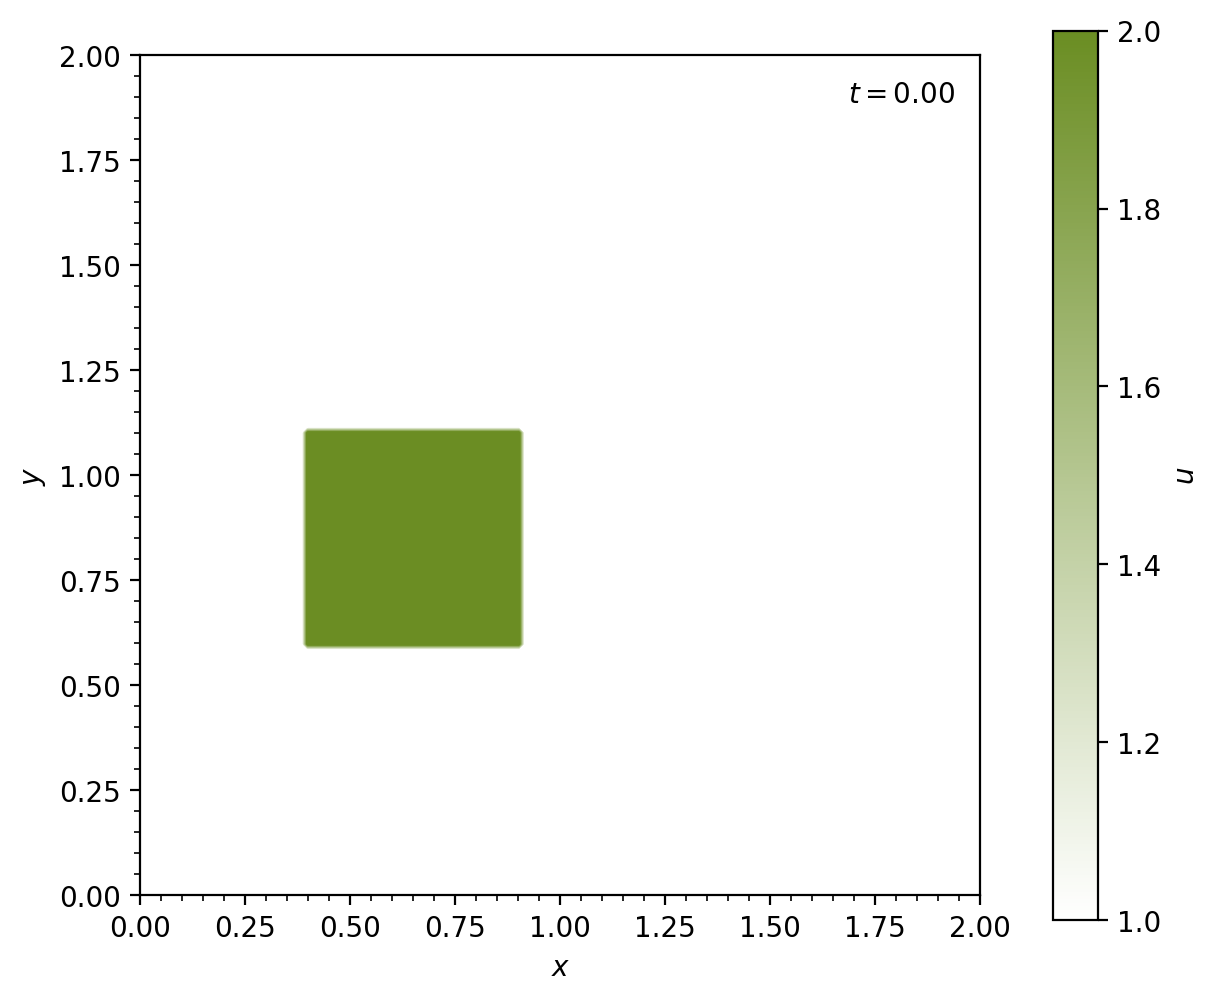

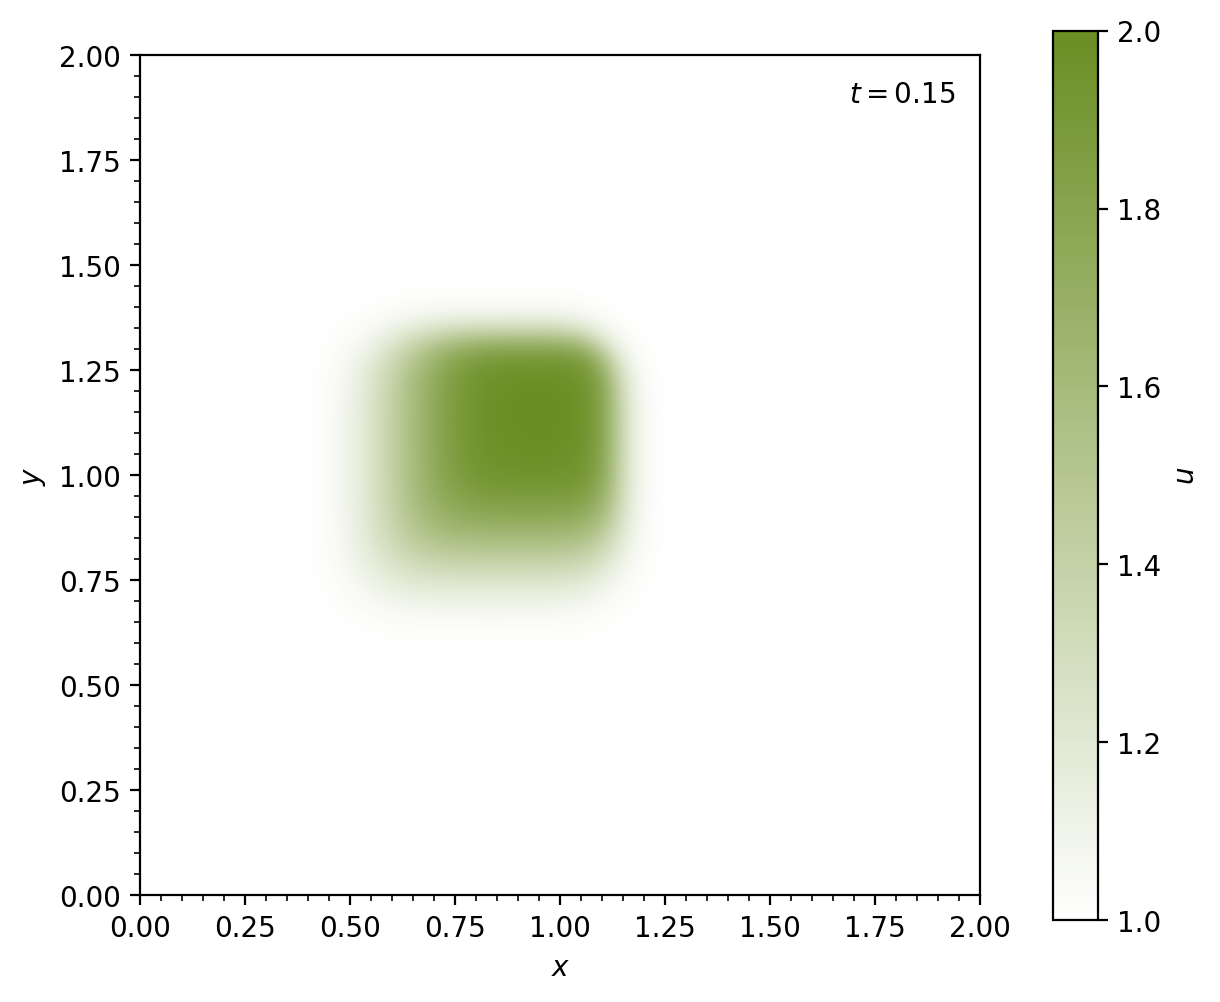

In [9]:
# Setup

nx = 201
ny = 201
nt = 17100
dx = 2 / (nx - 1)
dy = 2 / (ny - 1)
nu = .01
sigma = .0009
dt = sigma * dx * dy / nu

x = np.linspace(0, 2, nx)
y = np.linspace(0, 2, ny)

X, Y = np.meshgrid(x, y)                            

u = np.ones((ny, nx))
v = np.ones((ny, nx))

un = np.ones((ny, nx)) 
vn = np.ones((ny, nx))

u[int(.6 / dy):int(1.1 / dy + 1),int(.4 / dx):int(.9 / dx + 1)] = 2.
v[int(.6 / dy):int(1.1 / dy + 1),int(.4 / dx):int(.9 / dx + 1)] = 2.

# Initial

plt.plot([], [], ' ', label=f'$t = ${0.:.2f}')
cnt = plt.contourf(X, Y, u[:], levels=np.linspace(1, 2, 256), cmap=OliveDrab_r)
cnt.set_edgecolor('face')
cb = plt.colorbar(cnt, ticks=np.linspace(1, 2, 6), location='right')
cb.set_label(r'$u$')
plt.xlabel(r'$x$')
plt.ylabel(r'$y$')
plt.legend(loc='upper right')
plt.gca().set_aspect('equal', 'box')
plt.show()
plt.close()

# Evolution

k = 300

history = [u.copy()]

for n in range(nt):
    un = u.copy()
    vn = v.copy()

    u[1:-1, 1:-1] = (un[1:-1, 1:-1] - dt / dx * un[1:-1, 1:-1] * (un[1:-1, 1:-1] - un[1:-1, 0:-2]) - 
                     dt / dy * vn[1:-1, 1:-1] * (un[1:-1, 1:-1] - un[0:-2, 1:-1]) + nu * dt / dx**2 * 
                     (un[1:-1,2:] - 2 * un[1:-1, 1:-1] + un[1:-1, 0:-2]) + nu * dt / dy**2 * 
                     (un[2:, 1:-1] - 2 * un[1:-1, 1:-1] + un[0:-2, 1:-1]))
    
    v[1:-1, 1:-1] = (vn[1:-1, 1:-1] - dt / dx * un[1:-1, 1:-1] * (vn[1:-1, 1:-1] - vn[1:-1, 0:-2]) -
                     dt / dy * vn[1:-1, 1:-1] * (vn[1:-1, 1:-1] - vn[0:-2, 1:-1]) + nu * dt / dx**2 * 
                    (vn[1:-1, 2:] - 2 * vn[1:-1, 1:-1] + vn[1:-1, 0:-2]) + nu * dt / dy**2 *
                    (vn[2:, 1:-1] - 2 * vn[1:-1, 1:-1] + vn[0:-2, 1:-1]))
     
    u[0, :] = 1
    u[-1, :] = 1
    u[:, 0] = 1
    u[:, -1] = 1
    
    v[0, :] = 1
    v[-1, :] = 1
    v[:, 0] = 1
    v[:, -1] = 1

    if n % k == 0:
        history.append(u.copy())

# Final
                 
plt.plot([], [], ' ', label=f'$t = ${nt * dt:.2f}')
cnt = plt.contourf(X, Y, u[:], levels=np.linspace(1, 2, 256), cmap=OliveDrab_r)
cnt.set_edgecolor('face')
cb = plt.colorbar(cnt, ticks=np.linspace(1, 2, 6), location='right')
cb.set_label(r'$u$')
plt.xlabel(r'$x$')
plt.ylabel(r'$y$')
plt.legend()
plt.gca().set_aspect('equal', 'box')
plt.show()
plt.close()

# Animation

pause_number = 20
padded_history = ([history[0]] * pause_number) + history + ([history[-1]] * pause_number)

fig, ax = plt.subplots(dpi=150)
ax.plot([], [], ' ', label=f'$t = ${0.:.2f}')
leg = ax.legend(loc='upper right')
cnt = ax.contourf(X, Y, padded_history[0], levels=np.linspace(1, 2, 256), cmap=OliveDrab_r)
cnt.set_edgecolor('face')
cb = plt.colorbar(cnt, ticks=np.linspace(1, 2, 6), location='right')
cb.set_label(r'$u$')
plt.xlabel(r'$x$')
plt.ylabel(r'$y$')
ax.set_aspect('equal', 'box')

def update(frame):
    global cnt

    if cnt is not None:
        cnt.remove()
    
    cnt = ax.contourf(X, Y, padded_history[frame], levels=np.linspace(1, 2, 256), cmap=OliveDrab_r)
    display_frame = max(0, min(frame - pause_number, len(history) - 1))
    time = display_frame * k * dt
    leg.get_texts()[0].set_text(f'$t = ${time:.2f}')
    return []

ani = FuncAnimation(fig, update, frames=len(padded_history), interval=50, blit=False)

ani.save("2d_bate_burg_eq.gif", writer=PillowWriter(fps=20))

plt.close()
HTML('<img src="2d_bate_burg_eq.gif" width="600">')

### 2D Laplace Equation

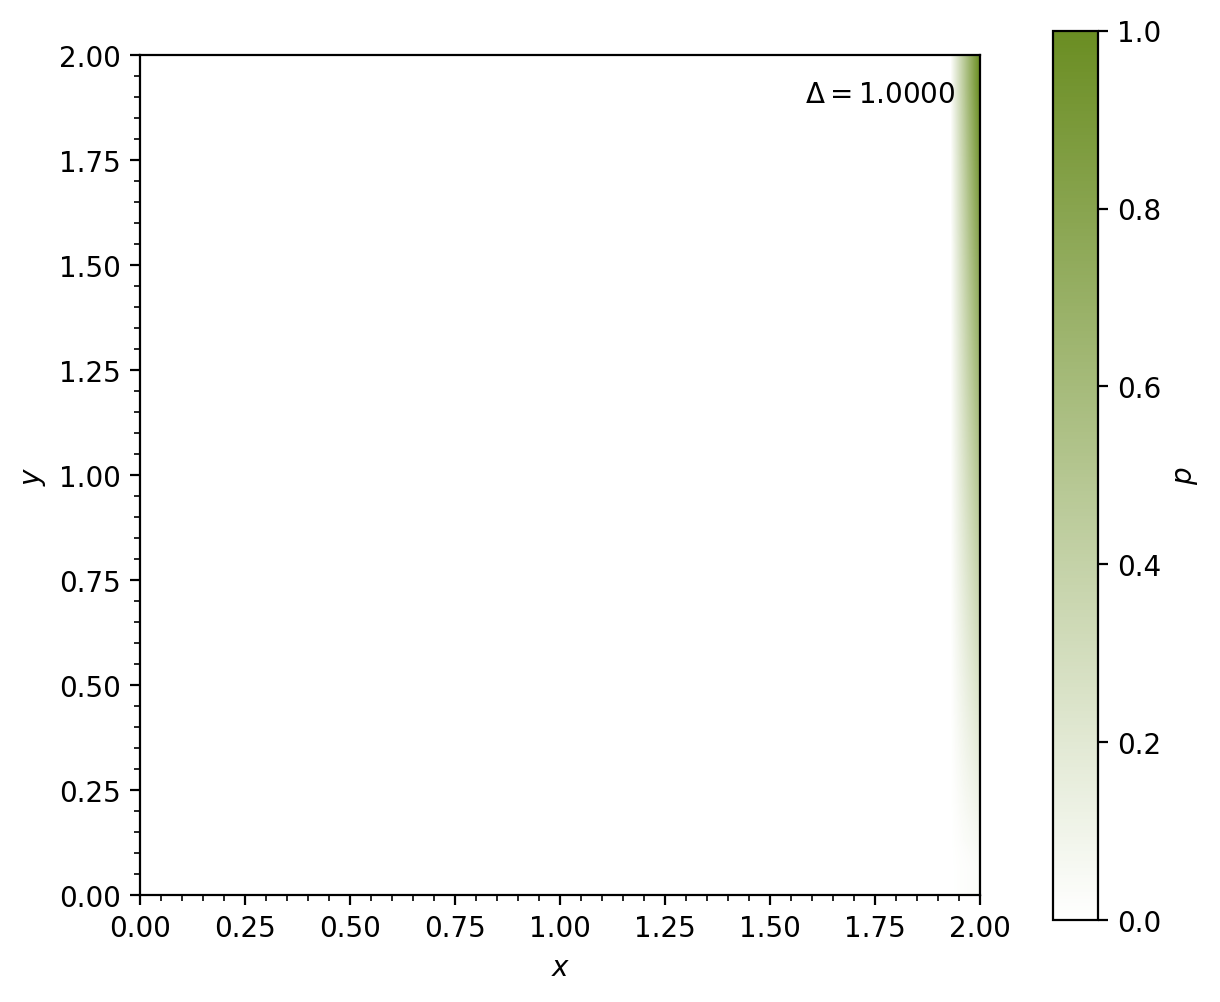

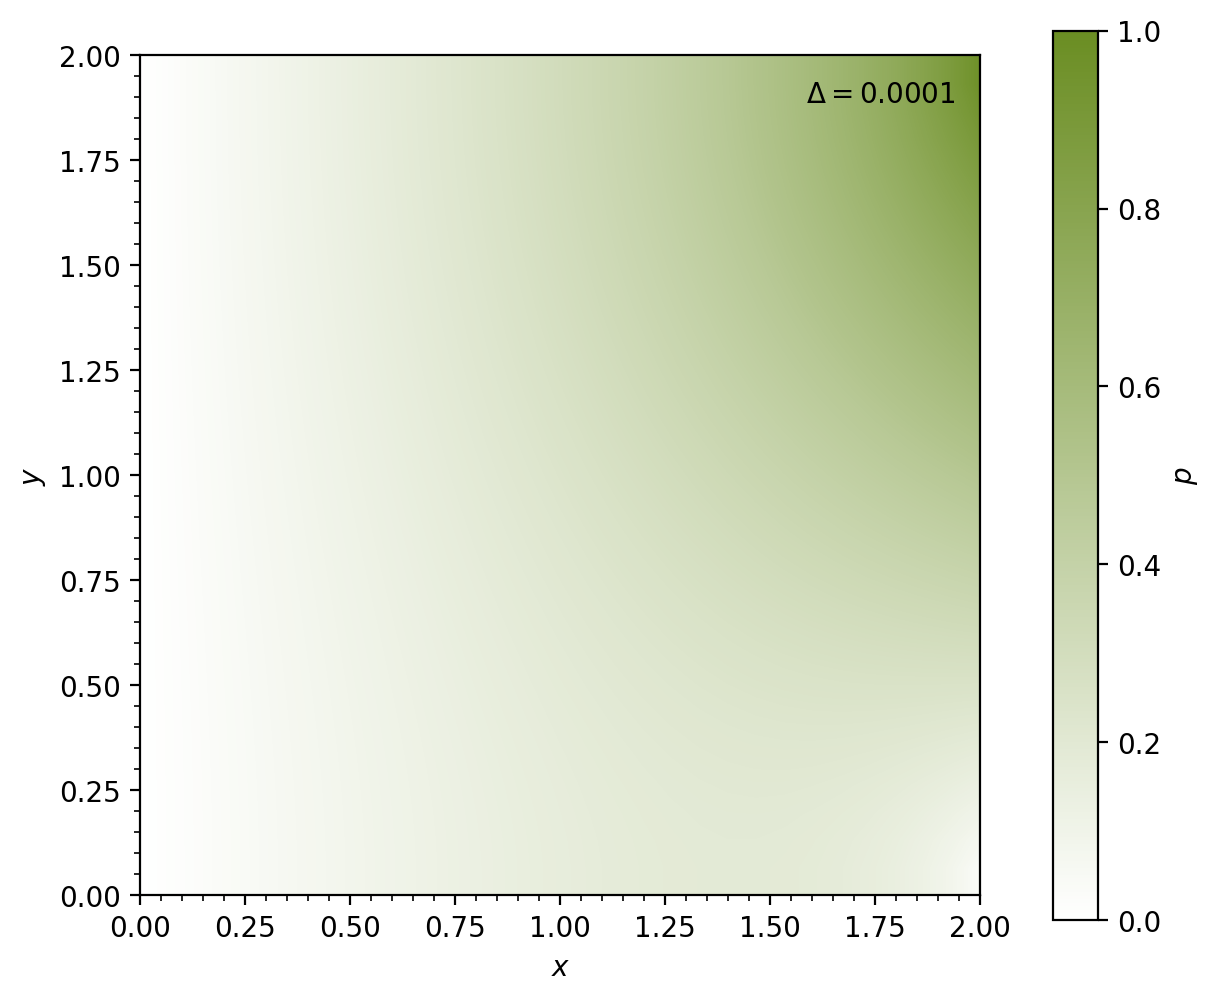

In [10]:
# Setup

nx = 31
ny = 31
dx = 2 / (nx - 1)
dy = 2 / (ny - 1)

x = np.linspace(0, 2, nx)
y = np.linspace(0, 2, ny)

X, Y = np.meshgrid(x, y)                            

p = np.zeros((ny, nx))

pn = np.zeros((ny, nx))

p[:, 0] = 0
p[:, -1] = y / 2
p[0, :] = p[1, :]
p[-1, :] = p[-2, :]

# Initial

plt.plot([], [], ' ', label=f'$\\Delta = ${1.:.4f}')
cnt = plt.contourf(X, Y, p[:], levels=np.linspace(0, 1, 256), cmap=OliveDrab_r)
cnt.set_edgecolor('face')
cb = plt.colorbar(cnt, ticks=np.linspace(0, 1, 6), location='right')
cb.set_label(r'$p$')
plt.xlabel(r'$x$')
plt.ylabel(r'$y$')
plt.legend(loc='upper right')
plt.gca().set_aspect('equal', 'box')
plt.show()
plt.close()

# Evolution

k = 15
n = 0

norm = 1.
target = .0001

history = [p.copy()]
step = [norm]

while norm > target:
    pn = p.copy()
    
    p[1:-1, 1:-1] = ((dy**2 * (pn[1:-1, 2:] + pn[1:-1, 0:-2]) + dx**2 * (pn[2:, 1:-1] + pn[0:-2, 1:-1])) / (2 * (dx**2 + dy**2)))
            
    p[:, 0] = 0
    p[:, -1] = y / 2
    p[0, :] = p[1, :]
    p[-1, :] = p[-2, :]
    
    norm = (np.sum(np.abs(p[:]) - np.abs(pn[:])) / np.sum(np.abs(pn[:])))

    if n % k == 0:
        history.append(p.copy())
        step.append(norm)

    n += 1


# Final
                 
plt.plot([], [], ' ', label=f'$\\Delta = ${norm:.4f}')
cnt = plt.contourf(X, Y, p[:], levels=np.linspace(0, 1, 256), cmap=OliveDrab_r)
cnt.set_edgecolor('face')
cb = plt.colorbar(cnt, ticks=np.linspace(0, 1, 6), location='right')
cb.set_label(r'$p$')
plt.xlabel(r'$x$')
plt.ylabel(r'$y$')
plt.legend()
plt.gca().set_aspect('equal', 'box')
plt.show()
plt.close()

# Animation

pause_number = 20
padded_history = ([history[0]] * pause_number) + history + ([history[-1]] * pause_number)
padded_step = ([step[0]] * pause_number) + step + ([step[-1]] * pause_number)

fig, ax = plt.subplots(dpi=150)
ax.plot([], [], ' ', label=f'$\\Delta = ${padded_step[0]:.4f}')
leg = ax.legend(loc='upper right')
cnt = ax.contourf(X, Y, padded_history[0], levels=np.linspace(0, 1, 256), cmap=OliveDrab_r)
cnt.set_edgecolor('face')
cb = plt.colorbar(cnt, ticks=np.linspace(0, 1, 6), location='right')
cb.set_label(r'$p$')
plt.xlabel(r'$x$')
plt.ylabel(r'$y$')
ax.set_aspect('equal', 'box')

def update(frame):
    global cnt

    if cnt is not None:
        cnt.remove()
    
    cnt = ax.contourf(X, Y, padded_history[frame], levels=np.linspace(0, 1, 256), cmap=OliveDrab_r)
    leg.get_texts()[0].set_text(f'$\\Delta = ${padded_step[frame]:.4f}')
    return cnt, leg

ani = FuncAnimation(fig, update, frames=len(padded_history), interval=50, blit=False)

ani.save("2d_lapla_eq.gif", writer=PillowWriter(fps=20))

plt.close()
HTML('<img src="2d_lapla_eq.gif" width="600">')

### 2D Poisson Equation

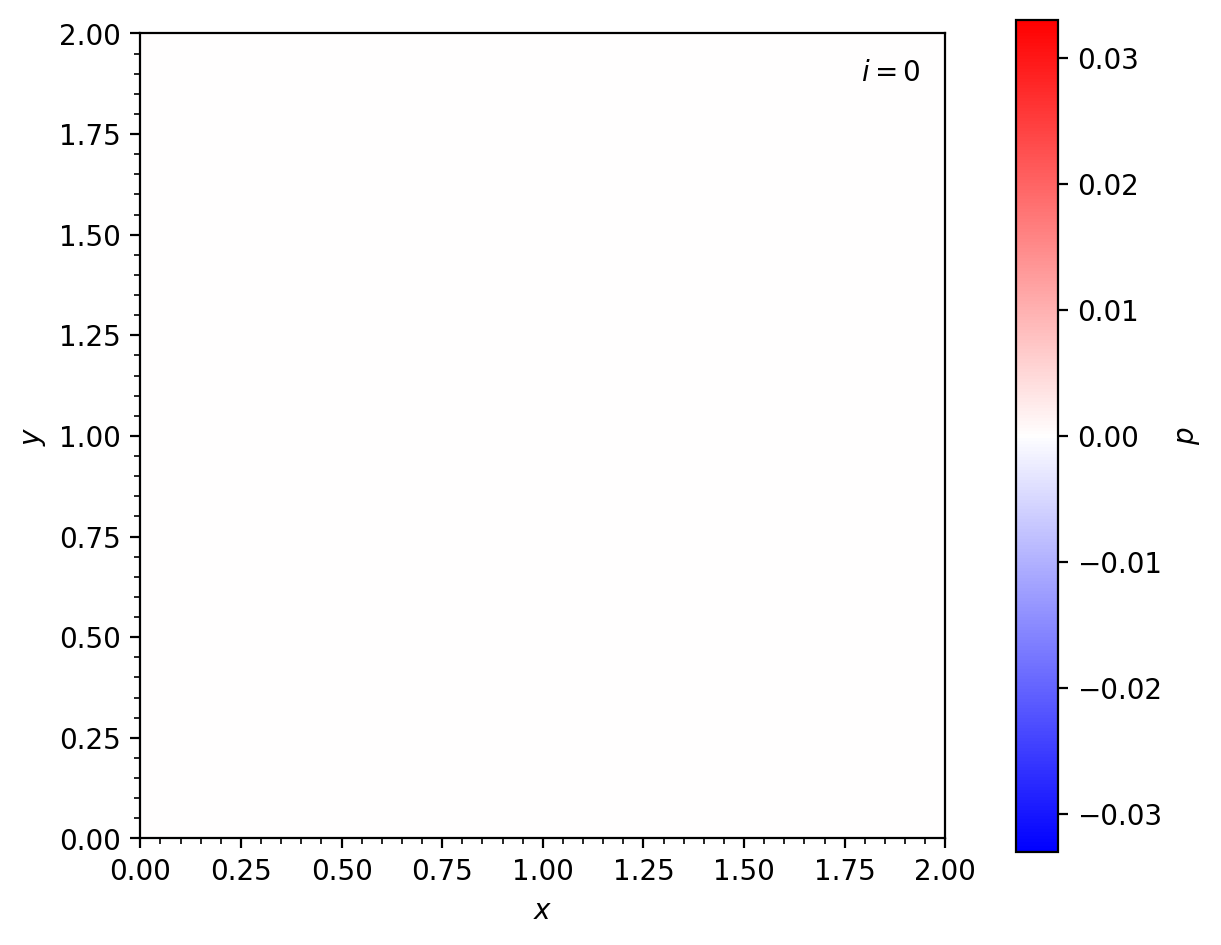

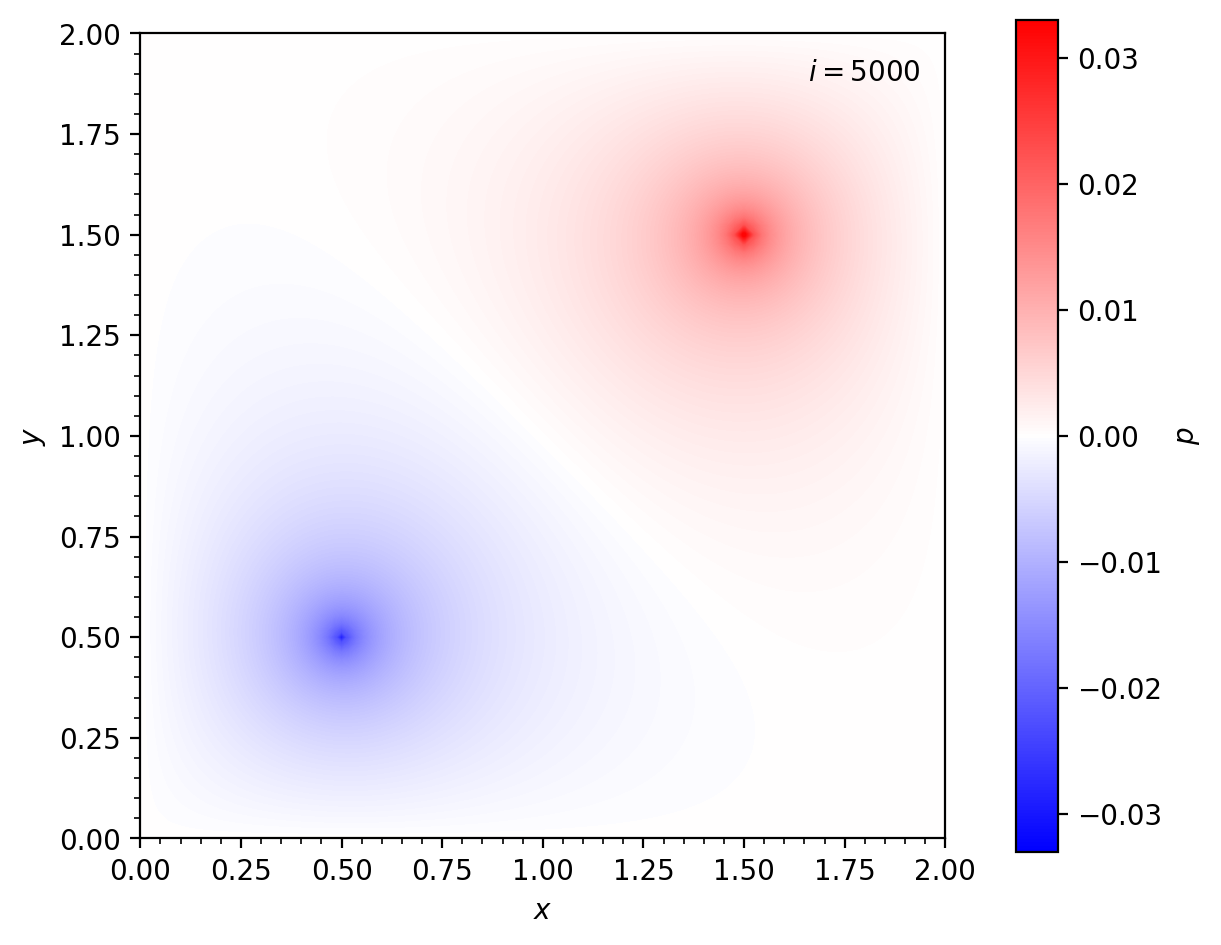

In [11]:
# Setup

nx = 101
ny = 101
nt  = 5000
xmin = 0
xmax = 2
ymin = 0
ymax = 2

dx = (xmax - xmin) / (nx - 1)
dy = (ymax - ymin) / (ny - 1)

p  = np.zeros((ny, nx))

pn = np.zeros((ny, nx))

b  = np.zeros((ny, nx))

x  = np.linspace(xmin, xmax, nx)
y  = np.linspace(xmin, xmax, ny)

X, Y = np.meshgrid(x, y)

b[int(.5 / dy), int(.5 / dx)]  = 100
b[int(1.5 / dy), int(1.5 / dx)] = -100

# Initial

plt.plot([], [], ' ', label=f'$i = ${0.:.0f}')
cnt = plt.contourf(X, Y, p[:], levels=np.linspace(-0.033, 0.033, 256), cmap='bwr')
cnt.set_edgecolor('face')
cb = plt.colorbar(cnt, ticks=np.linspace(-0.03, 0.03, 7), shrink=0.9, location='right')
cb.set_label(r'$p$')
plt.xlabel(r'$x$')
plt.ylabel(r'$y$')
plt.legend(loc='upper right')
plt.gca().set_aspect('equal', 'box')
plt.show()
plt.close()

# Evolution

k = 50

history = [p.copy()]

for it in range(nt):

    pn = p.copy()

    p[1:-1,1:-1] = (((pn[1:-1, 2:] + pn[1:-1, :-2]) * dy**2 + (pn[2:, 1:-1] + pn[:-2, 1:-1]) * dx**2 -
                    b[1:-1, 1:-1] * dx**2 * dy**2) / (2 * (dx**2 + dy**2)))

    p[0, :] = 0
    p[-1, :] = 0
    p[:, 0] = 0
    p[:, -1] = 0

    if it % k == 0:
        history.append(p.copy())

# Final
                 
plt.plot([], [], ' ', label=f'$i = ${nt:.0f}')
cnt = plt.contourf(X, Y, p[:], levels=np.linspace(-0.033, 0.033, 256), cmap='bwr')
cnt.set_edgecolor('face')
cb = plt.colorbar(cnt, ticks=np.linspace(-0.03, 0.03, 7), shrink=0.9, location='right')
cb.set_label(r'$p$')
plt.xlabel(r'$x$')
plt.ylabel(r'$y$')
plt.legend()
plt.gca().set_aspect('equal', 'box')
plt.show()
plt.close()

# Animation

pause_number = 20
padded_history = ([history[0]] * pause_number) + history + ([history[-1]] * pause_number)

fig, ax = plt.subplots(dpi=150)
ax.plot([], [], ' ', label=f'$i = ${0.:.0f}')
leg = ax.legend(loc='upper right')
cnt = plt.contourf(X, Y, padded_history[0], levels=np.linspace(-0.033, 0.033, 256), cmap='bwr')
cnt.set_edgecolor('face')
cb = plt.colorbar(cnt, ticks=np.linspace(-0.03, 0.03, 7), shrink=0.9, location='right')
cb.set_label(r'$p$')
plt.xlabel(r'$x$')
plt.ylabel(r'$y$')
ax.set_aspect('equal', 'box')

def update(frame):
    global cnt

    if cnt is not None:
        cnt.remove()
    
    cnt = ax.contourf(X, Y, padded_history[frame], levels=np.linspace(-0.033, 0.033, 256), cmap='bwr')
    display_frame = max(0, min(frame - pause_number, len(history) - 1))
    time = display_frame * k
    leg.get_texts()[0].set_text(f'$i = ${time:.0f}')
    return cnt, leg

ani = FuncAnimation(fig, update, frames=len(padded_history), interval=50, blit=False)

ani.save("2d_poisso_eq.gif", writer=PillowWriter(fps=20))

plt.close()
HTML('<img src="2d_poisso_eq.gif" width="600">')

### 2D Navier-Stokes: Lid-Driven Cavity Flow

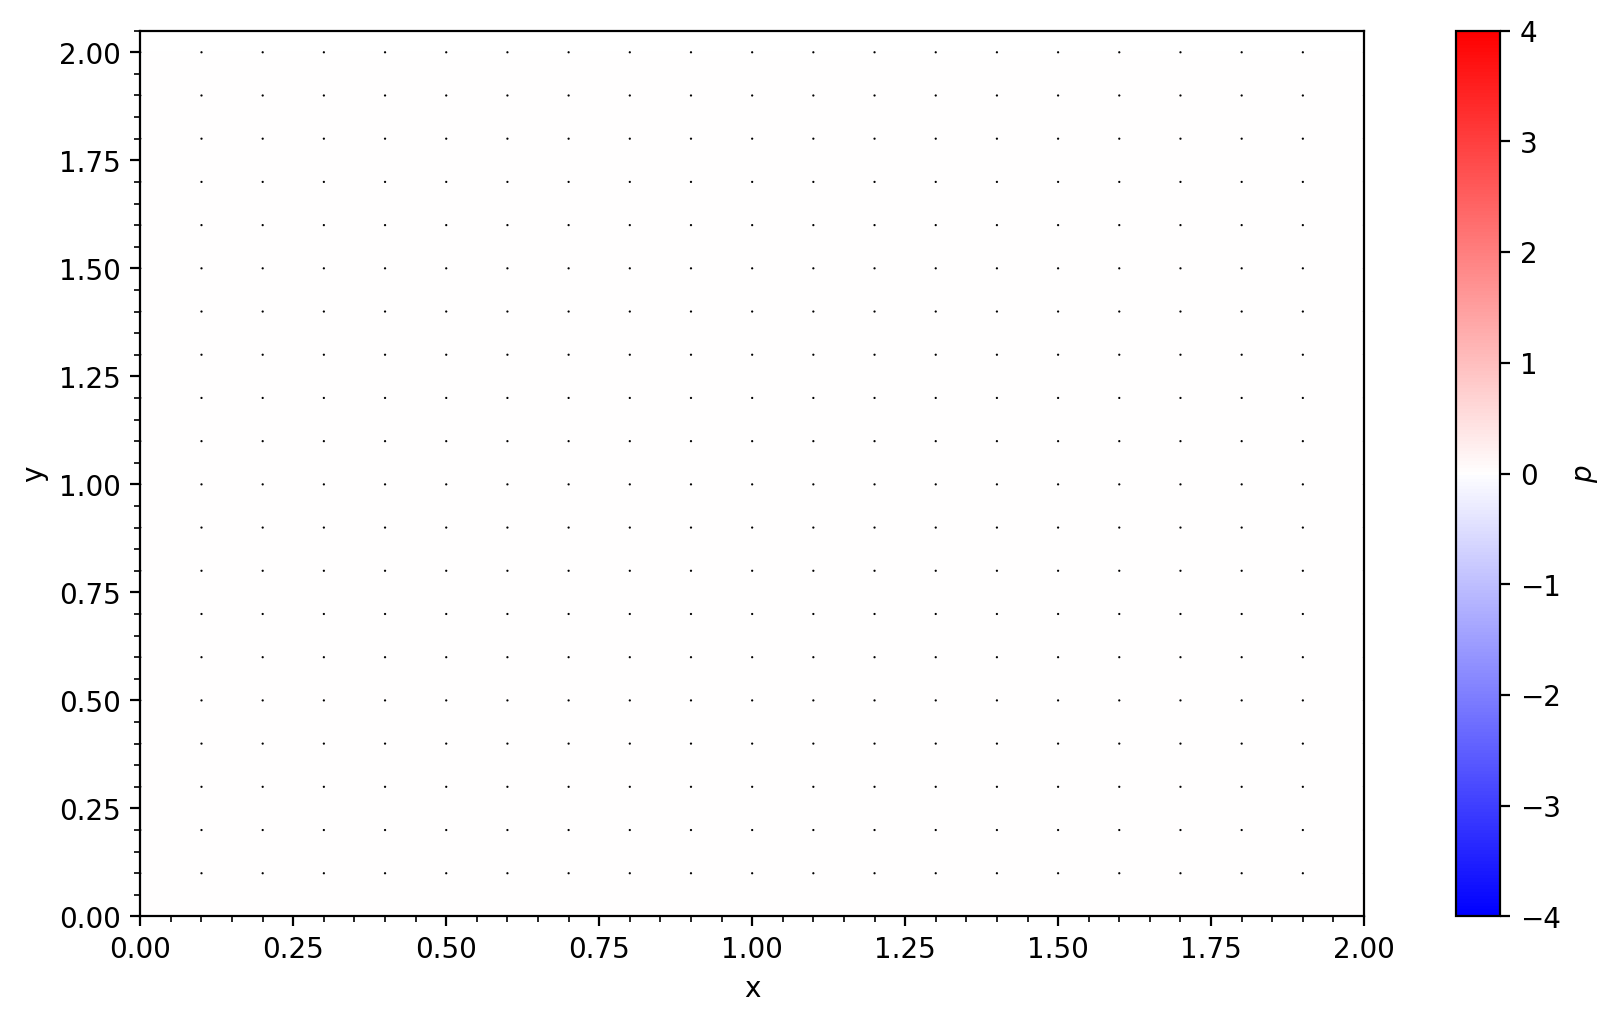

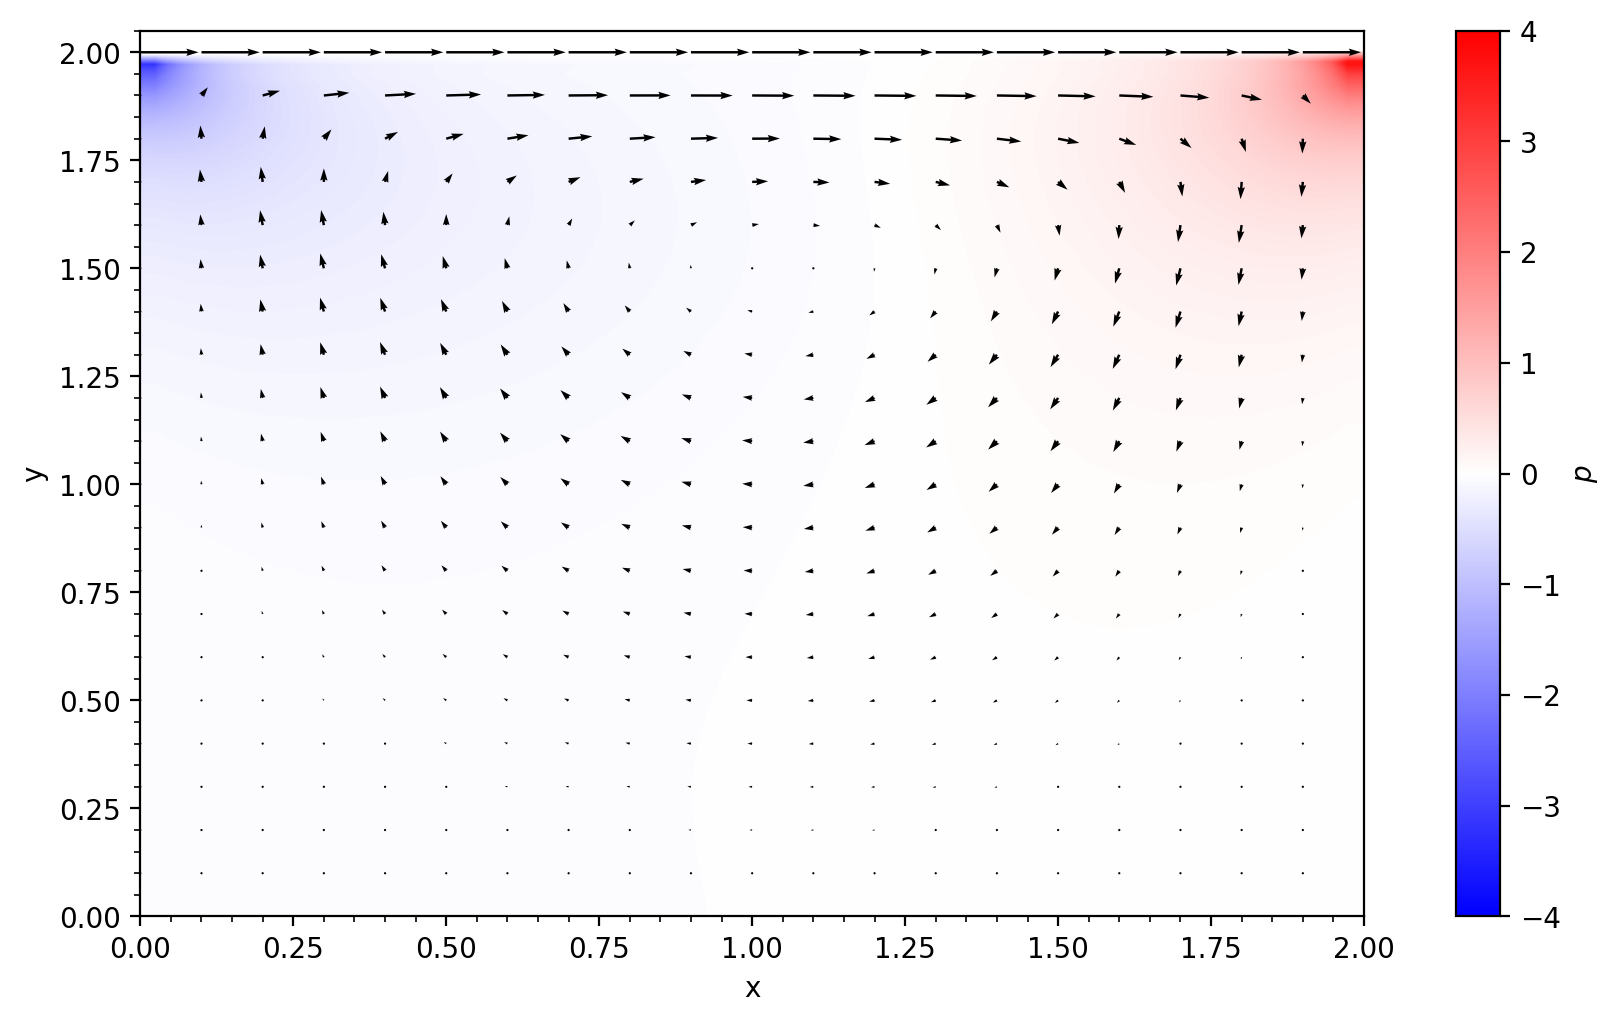

In [12]:
# Adjustment

plt.rcParams['figure.figsize'] = [8,5]

# Setup

def build_block(b, rho, dt, u, v, dx, dy):
    
    b[1:-1, 1:-1] = (rho * (1 / dt * 
                    ((u[1:-1, 2:] - u[1:-1, 0:-2]) / 
                     (2 * dx) + (v[2:, 1:-1] - v[0:-2, 1:-1]) / (2 * dy)) -
                    ((u[1:-1, 2:] - u[1:-1, 0:-2]) / (2 * dx))**2 -
                      2 * ((u[2:, 1:-1] - u[0:-2, 1:-1]) / (2 * dy) *
                           (v[1:-1, 2:] - v[1:-1, 0:-2]) / (2 * dx))-
                          ((v[2:, 1:-1] - v[0:-2, 1:-1]) / (2 * dy))**2))

    return b

def pressure_poisson(p, dx, dy, b):
    pn = np.empty_like(p)
    pn = p.copy()
    
    for q in range(nit):
        pn = p.copy()
        p[1:-1, 1:-1] = (((pn[1:-1, 2:] + pn[1:-1, 0:-2]) * dy**2 + 
                          (pn[2:, 1:-1] + pn[0:-2, 1:-1]) * dx**2) /
                          (2 * (dx**2 + dy**2)) -
                          dx**2 * dy**2 / (2 * (dx**2 + dy**2)) * 
                          b[1:-1,1:-1])

        p[:, -1] = p[:, -2]
        p[0, :] = p[1, :]
        p[:, 0] = p[:, 1]
        p[-1, :] = 0
        
    return p

nx = 81
ny = 81
nt = 1800
nit = 50
dx = 2 / (nx - 1)
dy = 2 / (ny - 1)
x = np.linspace(0, 2, nx)
y = np.linspace(0, 2, ny)
X, Y = np.meshgrid(x, y)

rho = 1
nu = .1
dt = .001

u = np.zeros((ny, nx))
v = np.zeros((ny, nx))

p = np.zeros((ny, nx))

b = np.zeros((ny, nx))

un = np.empty_like(u)
vn = np.empty_like(v)

# Initial

cnt = plt.contourf(X, Y, p, levels=np.linspace(-4, 4, 256), cmap='bwr')
cnt.set_edgecolor('face')
cb = plt.colorbar(cnt, ticks=np.linspace(-4, 4, 9), location='right')
cb.set_label(r'$p$')
plt.quiver(X[::4, ::4], Y[::4, ::4], u[::4, ::4], v[::4, ::4], scale=21, width=.002) 
plt.xlabel('x')
plt.ylabel('y')
plt.xlim(0, 2)
plt.ylim(0, 2.05)
plt.show()
plt.close()

# Evolution

k = 15

u_history = [u.copy()]
v_history = [v.copy()]

p_history = [p.copy()]

for n in range(nt):
    un = u.copy()
    vn = v.copy()
    
    b = build_block(b, rho, dt, u, v, dx, dy)
    p = pressure_poisson(p, dx, dy, b)
    
    u[1:-1, 1:-1] = (un[1:-1, 1:-1]-
                     un[1:-1, 1:-1] * dt / dx *
                    (un[1:-1, 1:-1] - un[1:-1, 0:-2]) -
                     vn[1:-1, 1:-1] * dt / dy *
                    (un[1:-1, 1:-1] - un[0:-2, 1:-1]) -
                     dt / (2 * rho * dx) * (p[1:-1, 2:] - p[1:-1, 0:-2]) +
                     nu * (dt / dx**2 *
                    (un[1:-1, 2:] - 2 * un[1:-1, 1:-1] + un[1:-1, 0:-2]) +
                     dt / dy**2 *
                    (un[2:, 1:-1] - 2 * un[1:-1, 1:-1] + un[0:-2, 1:-1])))

    v[1:-1,1:-1] = (vn[1:-1, 1:-1] -
                    un[1:-1, 1:-1] * dt / dx *
                   (vn[1:-1, 1:-1] - vn[1:-1, 0:-2]) -
                    vn[1:-1, 1:-1] * dt / dy *
                   (vn[1:-1, 1:-1] - vn[0:-2, 1:-1]) -
                    dt / (2 * rho * dy) * (p[2:, 1:-1] - p[0:-2, 1:-1]) +
                    nu * (dt / dx**2 *
                   (vn[1:-1, 2:] - 2 * vn[1:-1, 1:-1] + vn[1:-1, 0:-2]) +
                    dt / dy**2 *
                   (vn[2:, 1:-1] - 2 * vn[1:-1, 1:-1] + vn[0:-2, 1:-1])))

    u[0, :]  = 0
    u[:, 0]  = 0
    u[:, -1] = 0
    u[-1, :] = 1
    v[0, :]  = 0
    v[-1, :] = 0
    v[:, 0]  = 0
    v[:, -1] = 0

    if n % k == 0:
        u_history.append(u.copy())
        v_history.append(v.copy())
        
        p_history.append(p.copy())

# Final

cnt = plt.contourf(X, Y, p, levels=np.linspace(-4, 4, 256), cmap='bwr')
cnt.set_edgecolor('face')
cb = plt.colorbar(cnt, ticks=np.linspace(-4, 4, 9), location='right')
cb.set_label(r'$p$')
plt.quiver(X[::4, ::4], Y[::4, ::4], u[::4, ::4], v[::4, ::4], scale=21, width=.002) 
plt.xlabel('x')
plt.ylabel('y')
plt.xlim(0, 2)
plt.ylim(0, 2.05)
plt.show()
plt.close()

# Animation

pause_number = 20

padded_u_history = ([u_history[0]] * pause_number) + u_history + ([u_history[-1]] * pause_number)
padded_v_history = ([v_history[0]] * pause_number) + v_history + ([v_history[-1]] * pause_number)

padded_p_history = ([p_history[0]] * pause_number) + p_history + ([p_history[-1]] * pause_number)

fig, ax = plt.subplots(dpi=150)
cnt = plt.contourf(X, Y, padded_p_history[0], levels=np.linspace(-4, 4, 256), cmap='bwr', zorder=1)
cnt.set_edgecolor('face')
cb = plt.colorbar(cnt, ticks=np.linspace(-4, 4, 9), location='right')
cb.set_label(r'$p$')
qvr = plt.quiver(X[::4, ::4], Y[::4, ::4], padded_u_history[0][::4, ::4], padded_v_history[0][::4, ::4], scale=21, width=.002, zorder=1000)
plt.xlabel(r'$x$')
plt.ylabel(r'$y$')
plt.xlim(0, 2)
plt.ylim(0, 2.05)

def update(frame):
    global cnt, qvr

    if cnt is not None:
        cnt.remove()

    cnt = ax.contourf(X, Y, padded_p_history[frame], levels=np.linspace(-4, 4, 256), cmap='bwr', zorder=1)
    
    qvr.set_UVC(padded_u_history[frame][::4, ::4], padded_v_history[frame][::4, ::4])
    return cnt, qvr

ani = FuncAnimation(fig, update, frames=len(padded_p_history), interval=50, blit=False)

ani.save("2d_nav_stok_cavit.gif", writer=PillowWriter(fps=20))

plt.close()
HTML('<img src="2d_nav_stok_cavit.gif" width="800">')

### 2D Navier-Stokes: Pressure-Driven Channel Flow

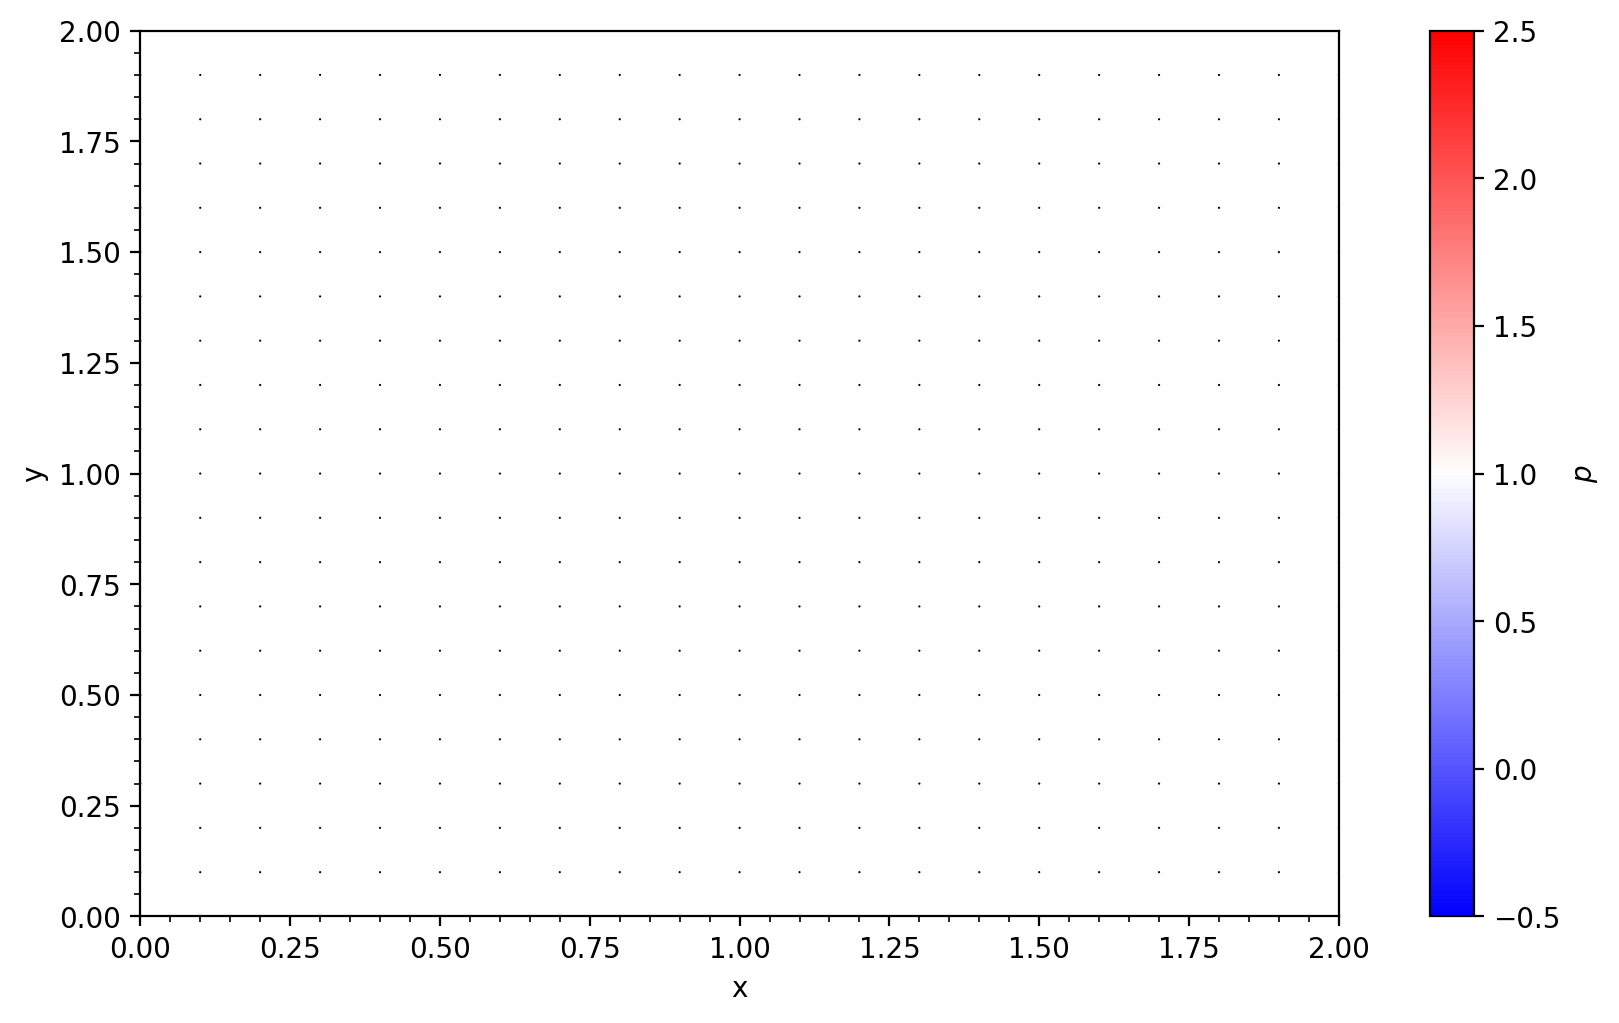

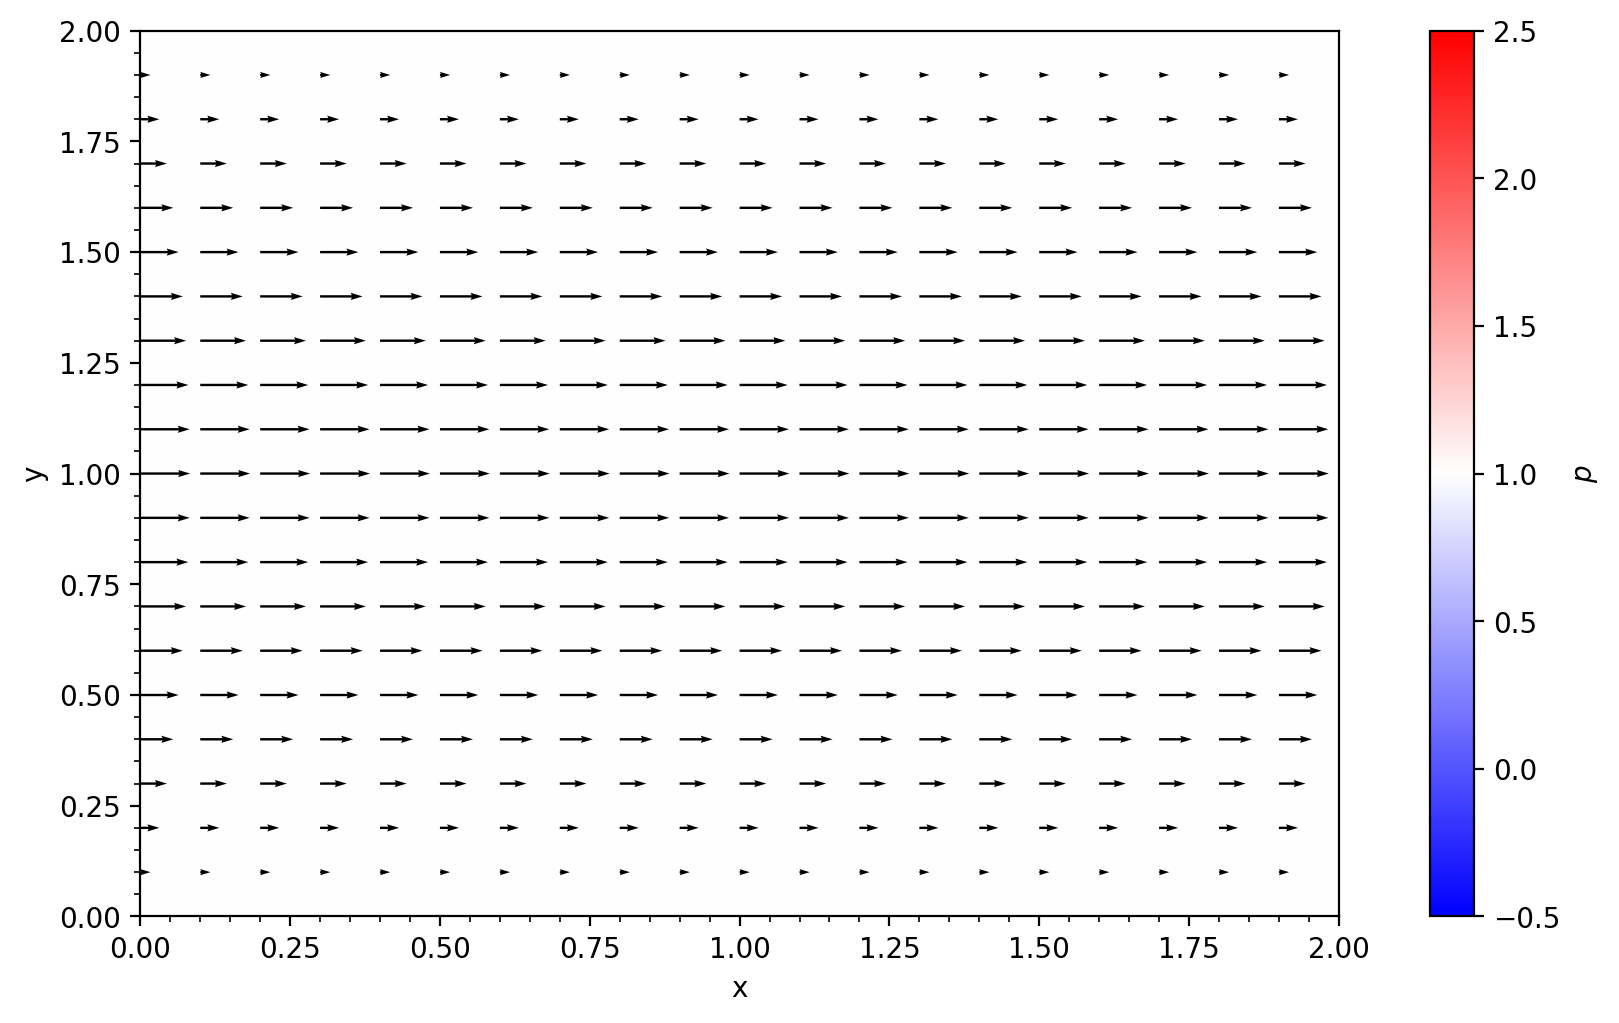

In [13]:
# Setup

def build_block(rho, dt, dx, dy, u, v):
    b = np.zeros_like(u)
    b[1:-1, 1:-1] = (rho * (1 / dt * ((u[1:-1, 2:] - u[1:-1, 0:-2]) / (2 * dx) +
                                      (v[2:, 1:-1] - v[0:-2, 1:-1]) / (2 * dy)) -
                            ((u[1:-1, 2:] - u[1:-1, 0:-2]) / (2 * dx))**2 -
                            2 * ((u[2:, 1:-1] - u[0:-2, 1:-1]) / (2 * dy) *
                                 (v[1:-1, 2:] - v[1:-1, 0:-2]) / (2 * dx))-
                            ((v[2:, 1:-1] - v[0:-2, 1:-1]) / (2 * dy))**2))
    
    b[1:-1, -1] = (rho * (1 / dt * ((u[1:-1, 0] - u[1:-1,-2]) / (2 * dx) +
                                    (v[2:, -1] - v[0:-2, -1]) / (2 * dy)) -
                          ((u[1:-1, 0] - u[1:-1, -2]) / (2 * dx))**2 -
                          2 * ((u[2:, -1] - u[0:-2, -1]) / (2 * dy) *
                               (v[1:-1, 0] - v[1:-1, -2]) / (2 * dx)) -
                          ((v[2:, -1] - v[0:-2, -1]) / (2 * dy))**2))

    b[1:-1, 0] = (rho * (1 / dt * ((u[1:-1, 1] - u[1:-1, -1]) / (2 * dx) +
                                   (v[2:, 0] - v[0:-2, 0]) / (2 * dy)) -
                         ((u[1:-1, 1] - u[1:-1, -1]) / (2 * dx))**2 -
                         2 * ((u[2:, 0] - u[0:-2, 0]) / (2 * dy) *
                              (v[1:-1, 1] - v[1:-1, -1]) / (2 * dx))-
                         ((v[2:, 0] - v[0:-2, 0]) / (2 * dy))**2))
    
    return b

def pressure_poisson(p, dx, dy):
    pn = np.empty_like(p)
    
    for q in range(nit):
        pn = p.copy()
        p[1:-1, 1:-1] = (((pn[1:-1, 2:] + pn[1:-1, 0:-2]) * dy**2 +
                          (pn[2:, 1:-1] + pn[0:-2, 1:-1]) * dx**2) /
                         (2 * (dx**2 + dy**2)) -
                         dx**2 * dy**2 / (2 * (dx**2 + dy**2)) * b[1:-1, 1:-1])

        p[1:-1, -1] = (((pn[1:-1, 0] + pn[1:-1, -2])* dy**2 +
                        (pn[2:, -1] + pn[0:-2, -1]) * dx**2) /
                       (2 * (dx**2 + dy**2)) -
                       dx**2 * dy**2 / (2 * (dx**2 + dy**2)) * b[1:-1, -1])

        p[1:-1, 0] = (((pn[1:-1, 1] + pn[1:-1, -1])* dy**2 +
                       (pn[2:, 0] + pn[0:-2, 0]) * dx**2) /
                      (2 * (dx**2 + dy**2)) -
                      dx**2 * dy**2 / (2 * (dx**2 + dy**2)) * b[1:-1, 0])
        
        p[-1, :] = p[-2, :]
        p[0, :] = p[1, :]
    
    return p

nx = 41
ny = 41
nit = 50
c = 1
dx = 2 / (nx - 1)
dy = 2 / (ny - 1)
x = np.linspace(0, 2, nx)
y = np.linspace(0, 2, ny)
X, Y = np.meshgrid(x, y)


rho = 1
nu = .1
F = 1
dt = .01

u = np.zeros((ny, nx))
un = np.zeros((ny, nx))

v = np.zeros((ny, nx))
vn = np.zeros((ny, nx))

p = np.ones((ny, nx))
pn = np.ones((ny, nx))

b = np.zeros((ny, nx))

# Initial

cnt = plt.contourf(X, Y, p, levels=np.linspace(-.5, 2.5, 256), cmap='bwr')
cnt.set_edgecolor('face')
cb = plt.colorbar(cnt, ticks=np.linspace(-.5, 2.5, 7), location='right')
cb.set_label(r'$p$')
plt.quiver(X[::2, ::2], Y[::2, ::2], u[::2, ::2], v[::2, ::2], scale=84, width=.002) 
plt.xlabel('x')
plt.ylabel('y')
plt.xlim(0, 2)
plt.ylim(0, 2)
plt.show()
plt.close()

# Evolution

k = 15

u_history = [u.copy()]
v_history = [v.copy()]

p_history = [p.copy()]

udiff = 1
stepcount = 0

while udiff > .001:
    un = u.copy()
    vn = v.copy()

    b = build_block(rho, dt, dx, dy, u, v)
    p = pressure_poisson(p, dx, dy)

    u[1:-1, 1:-1] = (un[1:-1, 1:-1] -
                     un[1:-1, 1:-1] * dt / dx * 
                    (un[1:-1, 1:-1] - un[1:-1, 0:-2]) -
                     vn[1:-1, 1:-1] * dt / dy * 
                    (un[1:-1, 1:-1] - un[0:-2, 1:-1]) -
                     dt / (2 * rho * dx) * 
                    (p[1:-1, 2:] - p[1:-1, 0:-2]) +
                     nu * (dt / dx**2 * 
                    (un[1:-1, 2:] - 2 * un[1:-1, 1:-1] + un[1:-1, 0:-2]) +
                     dt / dy**2 * 
                    (un[2:, 1:-1] - 2 * un[1:-1, 1:-1] + un[0:-2, 1:-1])) + 
                     F * dt)

    v[1:-1, 1:-1] = (vn[1:-1, 1:-1] -
                     un[1:-1, 1:-1] * dt / dx * 
                    (vn[1:-1, 1:-1] - vn[1:-1, 0:-2]) -
                     vn[1:-1, 1:-1] * dt / dy * 
                    (vn[1:-1, 1:-1] - vn[0:-2, 1:-1]) -
                     dt / (2 * rho * dy) * 
                    (p[2:, 1:-1] - p[0:-2, 1:-1]) +
                     nu * (dt / dx**2 *
                    (vn[1:-1, 2:] - 2 * vn[1:-1, 1:-1] + vn[1:-1, 0:-2]) +
                     dt / dy**2 * 
                    (vn[2:, 1:-1] - 2 * vn[1:-1, 1:-1] + vn[0:-2, 1:-1])))

    u[1:-1, -1] = (un[1:-1, -1] - un[1:-1, -1] * dt / dx * 
                  (un[1:-1, -1] - un[1:-1, -2]) -
                   vn[1:-1, -1] * dt / dy * 
                  (un[1:-1, -1] - un[0:-2, -1]) -
                   dt / (2 * rho * dx) *
                  (p[1:-1, 0] - p[1:-1, -2]) + 
                   nu * (dt / dx**2 * 
                  (un[1:-1, 0] - 2 * un[1:-1,-1] + un[1:-1, -2]) +
                   dt / dy**2 * 
                  (un[2:, -1] - 2 * un[1:-1, -1] + un[0:-2, -1])) + F * dt)

    u[1:-1, 0] = (un[1:-1, 0] - un[1:-1, 0] * dt / dx *
                 (un[1:-1, 0] - un[1:-1, -1]) -
                  vn[1:-1, 0] * dt / dy * 
                 (un[1:-1, 0] - un[0:-2, 0]) - 
                  dt / (2 * rho * dx) * 
                 (p[1:-1, 1] - p[1:-1, -1]) + 
                  nu * (dt / dx**2 * 
                 (un[1:-1, 1] - 2 * un[1:-1, 0] + un[1:-1, -1]) +
                  dt / dy**2 *
                 (un[2:, 0] - 2 * un[1:-1, 0] + un[0:-2, 0])) + F * dt)

    v[1:-1, -1] = (vn[1:-1, -1] - un[1:-1, -1] * dt / dx *
                  (vn[1:-1, -1] - vn[1:-1, -2]) - 
                   vn[1:-1, -1] * dt / dy *
                  (vn[1:-1, -1] - vn[0:-2, -1]) -
                   dt / (2 * rho * dy) * 
                  (p[2:, -1] - p[0:-2, -1]) +
                   nu * (dt / dx**2 *
                  (vn[1:-1, 0] - 2 * vn[1:-1, -1] + vn[1:-1, -2]) +
                   dt / dy**2 *
                  (vn[2:, -1] - 2 * vn[1:-1, -1] + vn[0:-2, -1])))

    v[1:-1, 0] = (vn[1:-1, 0] - un[1:-1, 0] * dt / dx *
                 (vn[1:-1, 0] - vn[1:-1, -1]) -
                  vn[1:-1, 0] * dt / dy *
                 (vn[1:-1, 0] - vn[0:-2, 0]) -
                  dt / (2 * rho * dy) * 
                 (p[2:, 0] - p[0:-2, 0]) +
                  nu * (dt / dx**2 * 
                 (vn[1:-1, 1] - 2 * vn[1:-1, 0] + vn[1:-1, -1]) +
                  dt / dy**2 * 
                 (vn[2:, 0] - 2 * vn[1:-1, 0] + vn[0:-2, 0])))


    u[0, :] = 0
    u[-1, :] = 0
    v[0, :] = 0
    v[-1, :] = 0

    udiff = (np.sum(u) - np.sum(un)) / np.sum(u)

    if stepcount % k == 0:
        u_history.append(u.copy())
        v_history.append(v.copy())
        
        p_history.append(p.copy())

    stepcount += 1

# Final

cnt = plt.contourf(X, Y, p, levels=np.linspace(-.5, 2.5, 256), cmap='bwr')
cnt.set_edgecolor('face')
cb = plt.colorbar(cnt, ticks=np.linspace(-.5, 2.5, 7), location='right')
cb.set_label(r'$p$')
plt.quiver(X[::2, ::2], Y[::2, ::2], u[::2, ::2], v[::2, ::2], scale=84, width=.002) 
plt.xlabel('x')
plt.ylabel('y')
plt.xlim(0, 2)
plt.ylim(0, 2)
plt.show()
plt.close()

# Animation

pause_number = 20

padded_u_history = ([u_history[0]] * pause_number) + u_history + ([u_history[-1]] * pause_number)
padded_v_history = ([v_history[0]] * pause_number) + v_history + ([v_history[-1]] * pause_number)

padded_p_history = ([p_history[0]] * pause_number) + p_history + ([p_history[-1]] * pause_number)

fig, ax = plt.subplots(dpi=150)
cnt = plt.contourf(X, Y, p, levels=np.linspace(-.5, 2.5, 256), cmap='bwr')
cnt.set_edgecolor('face')
cb = plt.colorbar(cnt, ticks=np.linspace(-.5, 2.5, 7), location='right')
cb.set_label(r'$p$')
qvr = plt.quiver(X[::2, ::2], Y[::2, ::2], padded_u_history[0][::2, ::2], padded_v_history[0][::2, ::2], scale=84, width=.002, zorder=1000)
plt.xlabel(r'$x$')
plt.ylabel(r'$y$')
plt.xlim(0, 2)
plt.ylim(0, 2)

def update(frame):    
    qvr.set_UVC(padded_u_history[frame][::2, ::2], padded_v_history[frame][::2, ::2])
    return qvr

ani = FuncAnimation(fig, update, frames=len(padded_p_history), interval=50, blit=False)

ani.save("2d_nav_stok_channe.gif", writer=PillowWriter(fps=20))

plt.close()
HTML('<img src="2d_nav_stok_channe.gif" width="800">')

### 2D Navier-Stokes: Modified Pressure-Driven Channel Flow

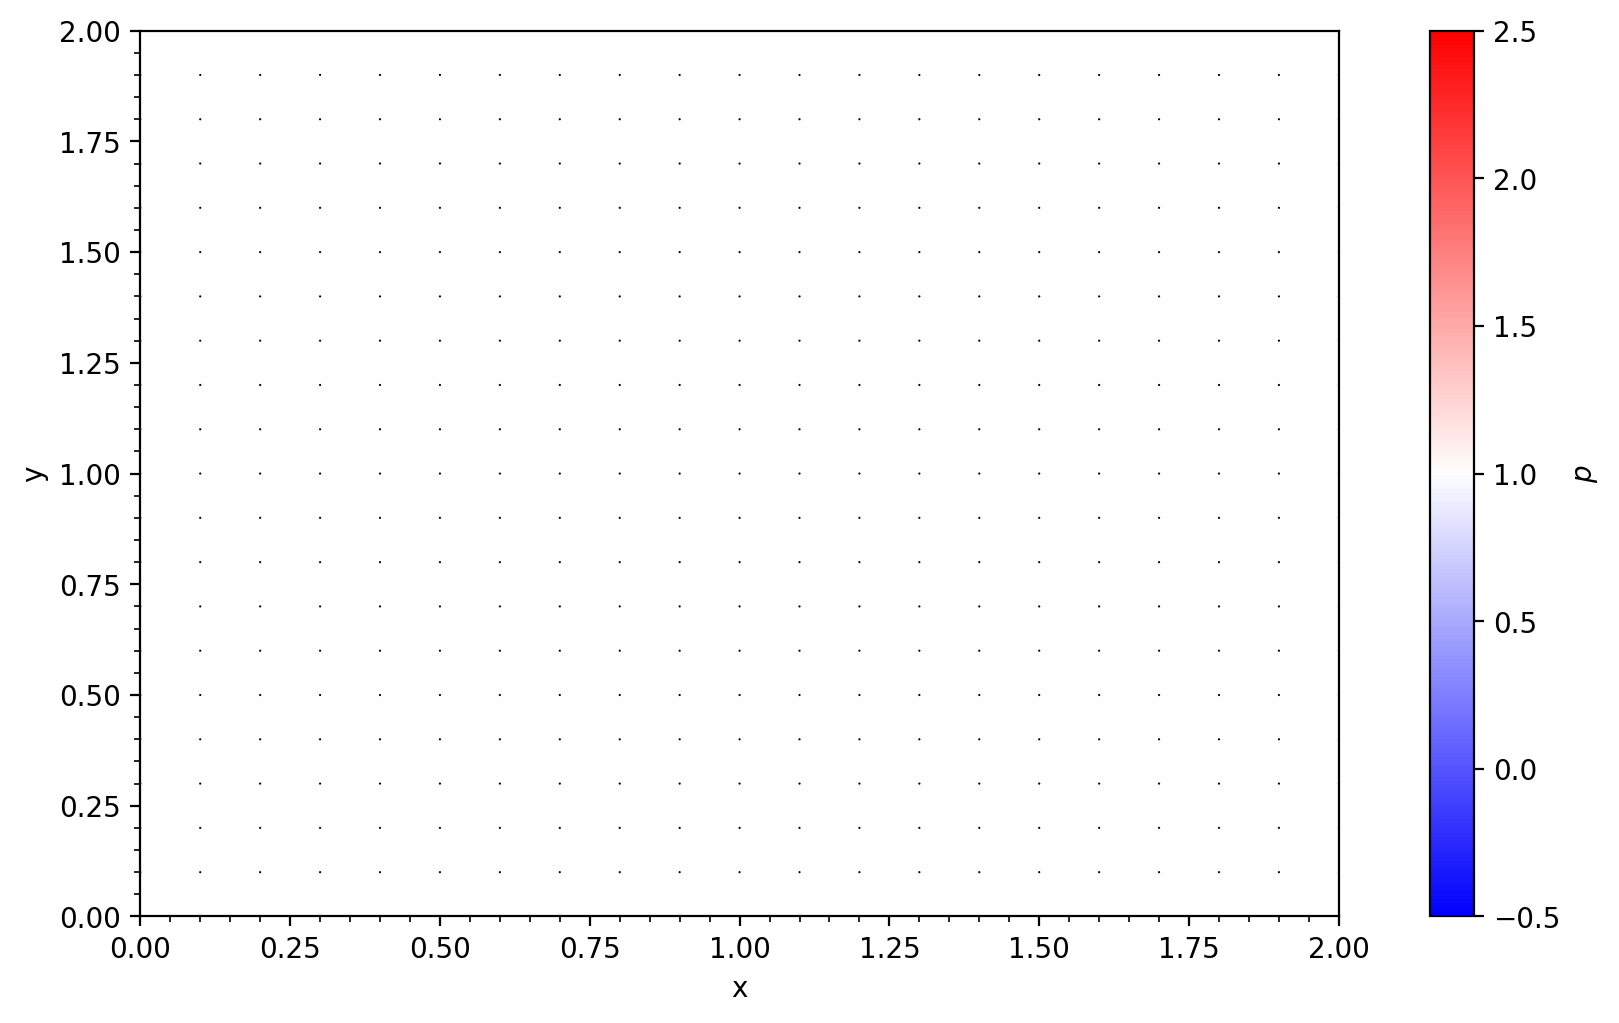

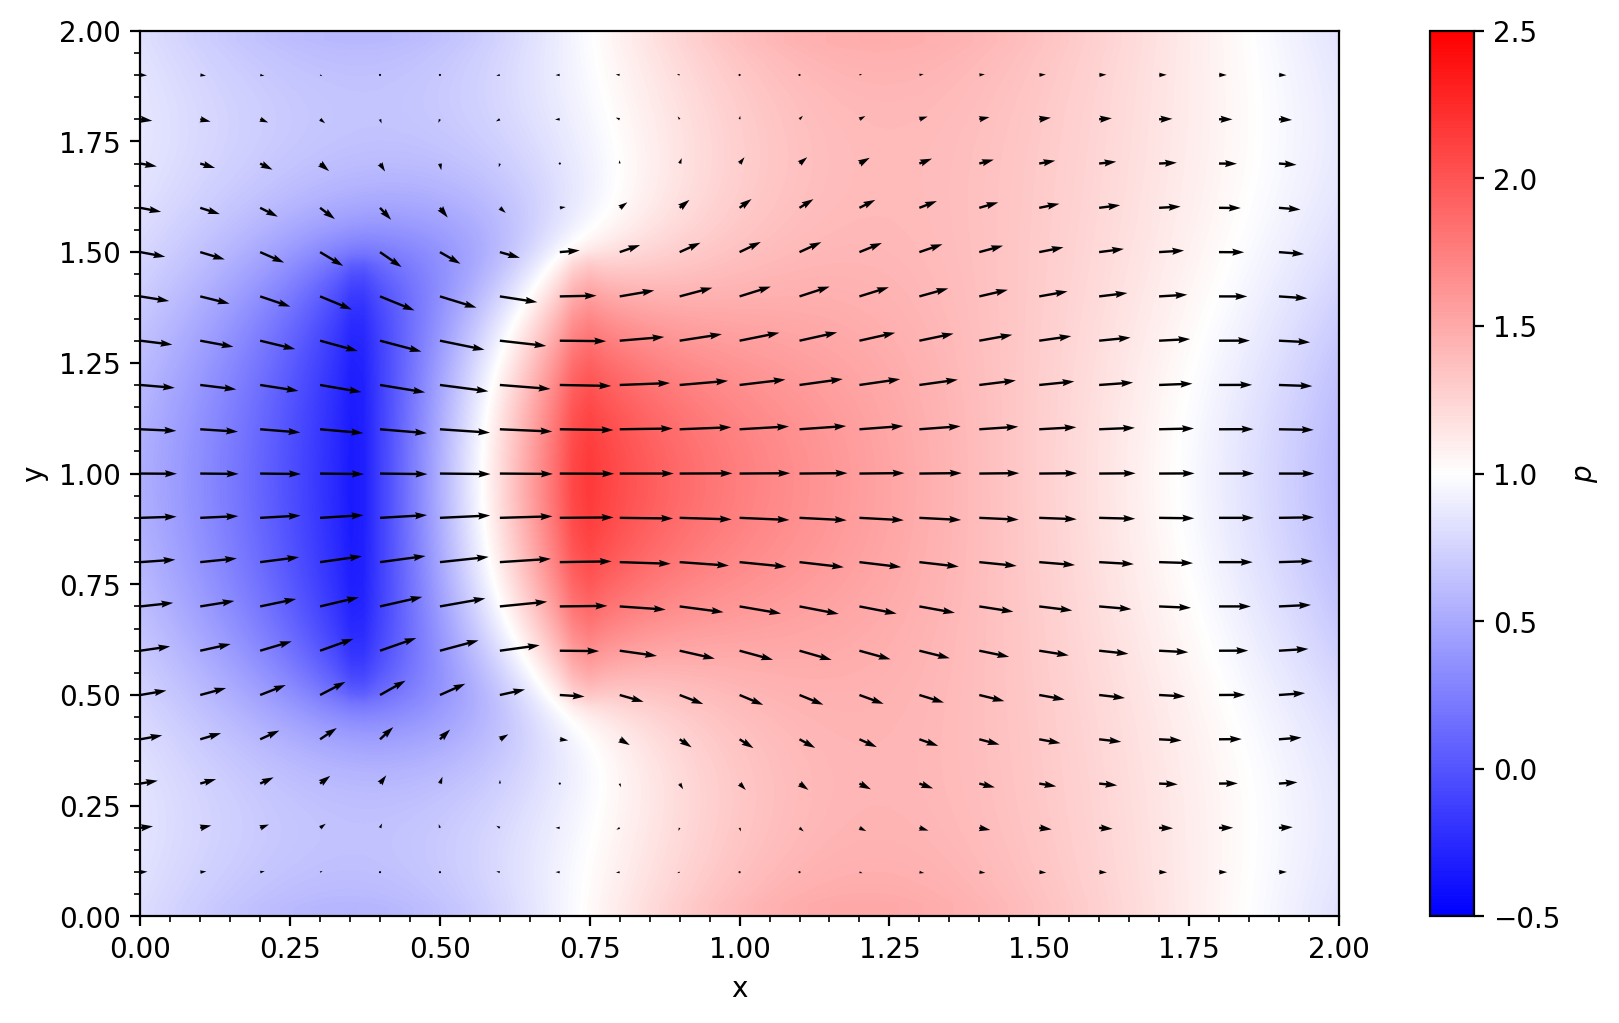

In [19]:
# Setup

def build_block(rho, dt, dx, dy, u, v):
    b = np.zeros_like(u)
    b[1:-1, 1:-1] = (rho * (1 / dt * ((u[1:-1, 2:] - u[1:-1, 0:-2]) / (2 * dx) +
                                      (v[2:, 1:-1] - v[0:-2, 1:-1]) / (2 * dy)) -
                            ((u[1:-1, 2:] - u[1:-1, 0:-2]) / (2 * dx))**2 -
                            2 * ((u[2:, 1:-1] - u[0:-2, 1:-1]) / (2 * dy) *
                                 (v[1:-1, 2:] - v[1:-1, 0:-2]) / (2 * dx))-
                            ((v[2:, 1:-1] - v[0:-2, 1:-1]) / (2 * dy))**2))
    
    b[1:-1, -1] = (rho * (1 / dt * ((u[1:-1, 0] - u[1:-1,-2]) / (2 * dx) +
                                    (v[2:, -1] - v[0:-2, -1]) / (2 * dy)) -
                          ((u[1:-1, 0] - u[1:-1, -2]) / (2 * dx))**2 -
                          2 * ((u[2:, -1] - u[0:-2, -1]) / (2 * dy) *
                               (v[1:-1, 0] - v[1:-1, -2]) / (2 * dx)) -
                          ((v[2:, -1] - v[0:-2, -1]) / (2 * dy))**2))

    b[1:-1, 0] = (rho * (1 / dt * ((u[1:-1, 1] - u[1:-1, -1]) / (2 * dx) +
                                   (v[2:, 0] - v[0:-2, 0]) / (2 * dy)) -
                         ((u[1:-1, 1] - u[1:-1, -1]) / (2 * dx))**2 -
                         2 * ((u[2:, 0] - u[0:-2, 0]) / (2 * dy) *
                              (v[1:-1, 1] - v[1:-1, -1]) / (2 * dx))-
                         ((v[2:, 0] - v[0:-2, 0]) / (2 * dy))**2))
    
    return b

def pressure_poisson(p, dx, dy):
    pn = np.empty_like(p)
    
    for q in range(nit):
        pn = p.copy()
        p[1:-1, 1:-1] = (((pn[1:-1, 2:] + pn[1:-1, 0:-2]) * dy**2 +
                          (pn[2:, 1:-1] + pn[0:-2, 1:-1]) * dx**2) /
                         (2 * (dx**2 + dy**2)) -
                         dx**2 * dy**2 / (2 * (dx**2 + dy**2)) * b[1:-1, 1:-1])

        p[1:-1, -1] = (((pn[1:-1, 0] + pn[1:-1, -2])* dy**2 +
                        (pn[2:, -1] + pn[0:-2, -1]) * dx**2) /
                       (2 * (dx**2 + dy**2)) -
                       dx**2 * dy**2 / (2 * (dx**2 + dy**2)) * b[1:-1, -1])

        p[1:-1, 0] = (((pn[1:-1, 1] + pn[1:-1, -1])* dy**2 +
                       (pn[2:, 0] + pn[0:-2, 0]) * dx**2) /
                      (2 * (dx**2 + dy**2)) -
                      dx**2 * dy**2 / (2 * (dx**2 + dy**2)) * b[1:-1, 0])
        
        p[-1, :] = p[-2, :]
        p[0, :] = p[1, :]
    
    return p

nx = 81
ny = 81
nit = 100
dx = 2 / (nx - 1)
dy = 2 / (ny - 1)
x = np.linspace(0, 2, nx)
y = np.linspace(0, 2, ny)
X, Y = np.meshgrid(x, y)

rho = 1
nu = .1

F = np.zeros((ny, nx))
F[20:60, 15:30] = 10.

dt = .001

u = np.zeros((ny, nx))
un = np.zeros((ny, nx))

v = np.zeros((ny, nx))
vn = np.zeros((ny, nx))

p = np.ones((ny, nx))
pn = np.ones((ny, nx))

b = np.zeros((ny, nx))

# Initial

cnt = plt.contourf(X, Y, p, levels=np.linspace(-.5, 2.5, 256), cmap='bwr')
cnt.set_edgecolor('face')
cb = plt.colorbar(cnt, ticks=np.linspace(-.5, 2.5, 7), location='right')
cb.set_label(r'$p$')
plt.quiver(X[::4, ::4], Y[::4, ::4], u[::4, ::4], v[::4, ::4], scale=42, width=.002) 
plt.xlabel('x')
plt.ylabel('y')
plt.xlim(0, 2)
plt.ylim(0, 2)
plt.show()
plt.close()

# Evolution

k = 20

u_history = [u.copy()]
v_history = [v.copy()]

p_history = [p.copy()]

udiff = 1
stepcount = 0

while udiff > .001:
    un = u.copy()
    vn = v.copy()

    b = build_block(rho, dt, dx, dy, u, v)
    p = pressure_poisson(p, dx, dy)

    u[1:-1, 1:-1] = (un[1:-1, 1:-1] -
                     un[1:-1, 1:-1] * dt / dx * 
                    (un[1:-1, 1:-1] - un[1:-1, 0:-2]) -
                     vn[1:-1, 1:-1] * dt / dy * 
                    (un[1:-1, 1:-1] - un[0:-2, 1:-1]) -
                     dt / (2 * rho * dx) * 
                    (p[1:-1, 2:] - p[1:-1, 0:-2]) +
                     nu * (dt / dx**2 * 
                    (un[1:-1, 2:] - 2 * un[1:-1, 1:-1] + un[1:-1, 0:-2]) +
                     dt / dy**2 * 
                    (un[2:, 1:-1] - 2 * un[1:-1, 1:-1] + un[0:-2, 1:-1])) + 
                     F[1:-1, 1:-1] * dt)

    v[1:-1, 1:-1] = (vn[1:-1, 1:-1] -
                     un[1:-1, 1:-1] * dt / dx * 
                    (vn[1:-1, 1:-1] - vn[1:-1, 0:-2]) -
                     vn[1:-1, 1:-1] * dt / dy * 
                    (vn[1:-1, 1:-1] - vn[0:-2, 1:-1]) -
                     dt / (2 * rho * dy) * 
                    (p[2:, 1:-1] - p[0:-2, 1:-1]) +
                     nu * (dt / dx**2 *
                    (vn[1:-1, 2:] - 2 * vn[1:-1, 1:-1] + vn[1:-1, 0:-2]) +
                     dt / dy**2 * 
                    (vn[2:, 1:-1] - 2 * vn[1:-1, 1:-1] + vn[0:-2, 1:-1])))

    u[1:-1, -1] = (un[1:-1, -1] - un[1:-1, -1] * dt / dx * 
                  (un[1:-1, -1] - un[1:-1, -2]) -
                   vn[1:-1, -1] * dt / dy * 
                  (un[1:-1, -1] - un[0:-2, -1]) -
                   dt / (2 * rho * dx) *
                  (p[1:-1, 0] - p[1:-1, -2]) + 
                   nu * (dt / dx**2 * 
                  (un[1:-1, 0] - 2 * un[1:-1,-1] + un[1:-1, -2]) +
                   dt / dy**2 * 
                  (un[2:, -1] - 2 * un[1:-1, -1] + un[0:-2, -1])) + F[1:-1, -1] * dt)

    u[1:-1, 0] = (un[1:-1, 0] - un[1:-1, 0] * dt / dx *
                 (un[1:-1, 0] - un[1:-1, -1]) -
                  vn[1:-1, 0] * dt / dy * 
                 (un[1:-1, 0] - un[0:-2, 0]) - 
                  dt / (2 * rho * dx) * 
                 (p[1:-1, 1] - p[1:-1, -1]) + 
                  nu * (dt / dx**2 * 
                 (un[1:-1, 1] - 2 * un[1:-1, 0] + un[1:-1, -1]) +
                  dt / dy**2 *
                 (un[2:, 0] - 2 * un[1:-1, 0] + un[0:-2, 0])) + F[1:-1, 0] * dt)

    v[1:-1, -1] = (vn[1:-1, -1] - un[1:-1, -1] * dt / dx *
                  (vn[1:-1, -1] - vn[1:-1, -2]) - 
                   vn[1:-1, -1] * dt / dy *
                  (vn[1:-1, -1] - vn[0:-2, -1]) -
                   dt / (2 * rho * dy) * 
                  (p[2:, -1] - p[0:-2, -1]) +
                   nu * (dt / dx**2 *
                  (vn[1:-1, 0] - 2 * vn[1:-1, -1] + vn[1:-1, -2]) +
                   dt / dy**2 *
                  (vn[2:, -1] - 2 * vn[1:-1, -1] + vn[0:-2, -1])))

    v[1:-1, 0] = (vn[1:-1, 0] - un[1:-1, 0] * dt / dx *
                 (vn[1:-1, 0] - vn[1:-1, -1]) -
                  vn[1:-1, 0] * dt / dy *
                 (vn[1:-1, 0] - vn[0:-2, 0]) -
                  dt / (2 * rho * dy) * 
                 (p[2:, 0] - p[0:-2, 0]) +
                  nu * (dt / dx**2 * 
                 (vn[1:-1, 1] - 2 * vn[1:-1, 0] + vn[1:-1, -1]) +
                  dt / dy**2 * 
                 (vn[2:, 0] - 2 * vn[1:-1, 0] + vn[0:-2, 0])))


    u[0, :] = 0
    u[-1, :] = 0
    v[0, :] = 0
    v[-1, :] = 0

    udiff = (np.sum(u) - np.sum(un)) / np.sum(u)

    if stepcount % k == 0:
        u_history.append(u.copy())
        v_history.append(v.copy())
        
        p_history.append(p.copy())

    stepcount += 1

# Final

cnt = plt.contourf(X, Y, p, levels=np.linspace(-.5, 2.5, 256), cmap='bwr')
cnt.set_edgecolor('face')
cb = plt.colorbar(cnt, ticks=np.linspace(-.5, 2.5, 7), location='right')
cb.set_label(r'$p$')
plt.quiver(X[::4, ::4], Y[::4, ::4], u[::4, ::4], v[::4, ::4], scale=42, width=.002) 
plt.xlabel('x')
plt.ylabel('y')
plt.xlim(0, 2)
plt.ylim(0, 2)
plt.show()
plt.close()

# Animation

pause_number = 20

padded_u_history = ([u_history[0]] * pause_number) + u_history + ([u_history[-1]] * pause_number)
padded_v_history = ([v_history[0]] * pause_number) + v_history + ([v_history[-1]] * pause_number)

padded_p_history = ([p_history[0]] * pause_number) + p_history + ([p_history[-1]] * pause_number)

fig, ax = plt.subplots(dpi=150)
cnt = plt.contourf(X, Y, padded_p_history[0], levels=np.linspace(-.5, 2.5, 256), cmap='bwr', zorder=1)
cnt.set_edgecolor('face')
cb = plt.colorbar(cnt, ticks=np.linspace(-.5, 2.5, 7), location='right')
cb.set_label(r'$p$')
qvr = plt.quiver(X[::4, ::4], Y[::4, ::4], padded_u_history[0][::4, ::4], padded_v_history[0][::4, ::4], scale=42, width=.002, zorder=1000)
plt.xlabel(r'$x$')
plt.ylabel(r'$y$')
plt.xlim(0, 2)
plt.ylim(0, 2)

def update(frame):
    global cnt, qvr

    if cnt is not None:
        cnt.remove()

    cnt = ax.contourf(X, Y, padded_p_history[frame], levels=np.linspace(-.5, 2.5, 256), cmap='bwr', zorder=1)
    
    qvr.set_UVC(padded_u_history[frame][::4, ::4], padded_v_history[frame][::4, ::4])
    return cnt, qvr

ani = FuncAnimation(fig, update, frames=len(padded_p_history), interval=50, blit=False)

ani.save("2d_nav_stok_channe_mod.gif", writer=PillowWriter(fps=20))

plt.close()
HTML('<img src="2d_nav_stok_channe_mod.gif" width="800">')

### 2D Navier-Stokes: Kelvin-Helmholtz Instability

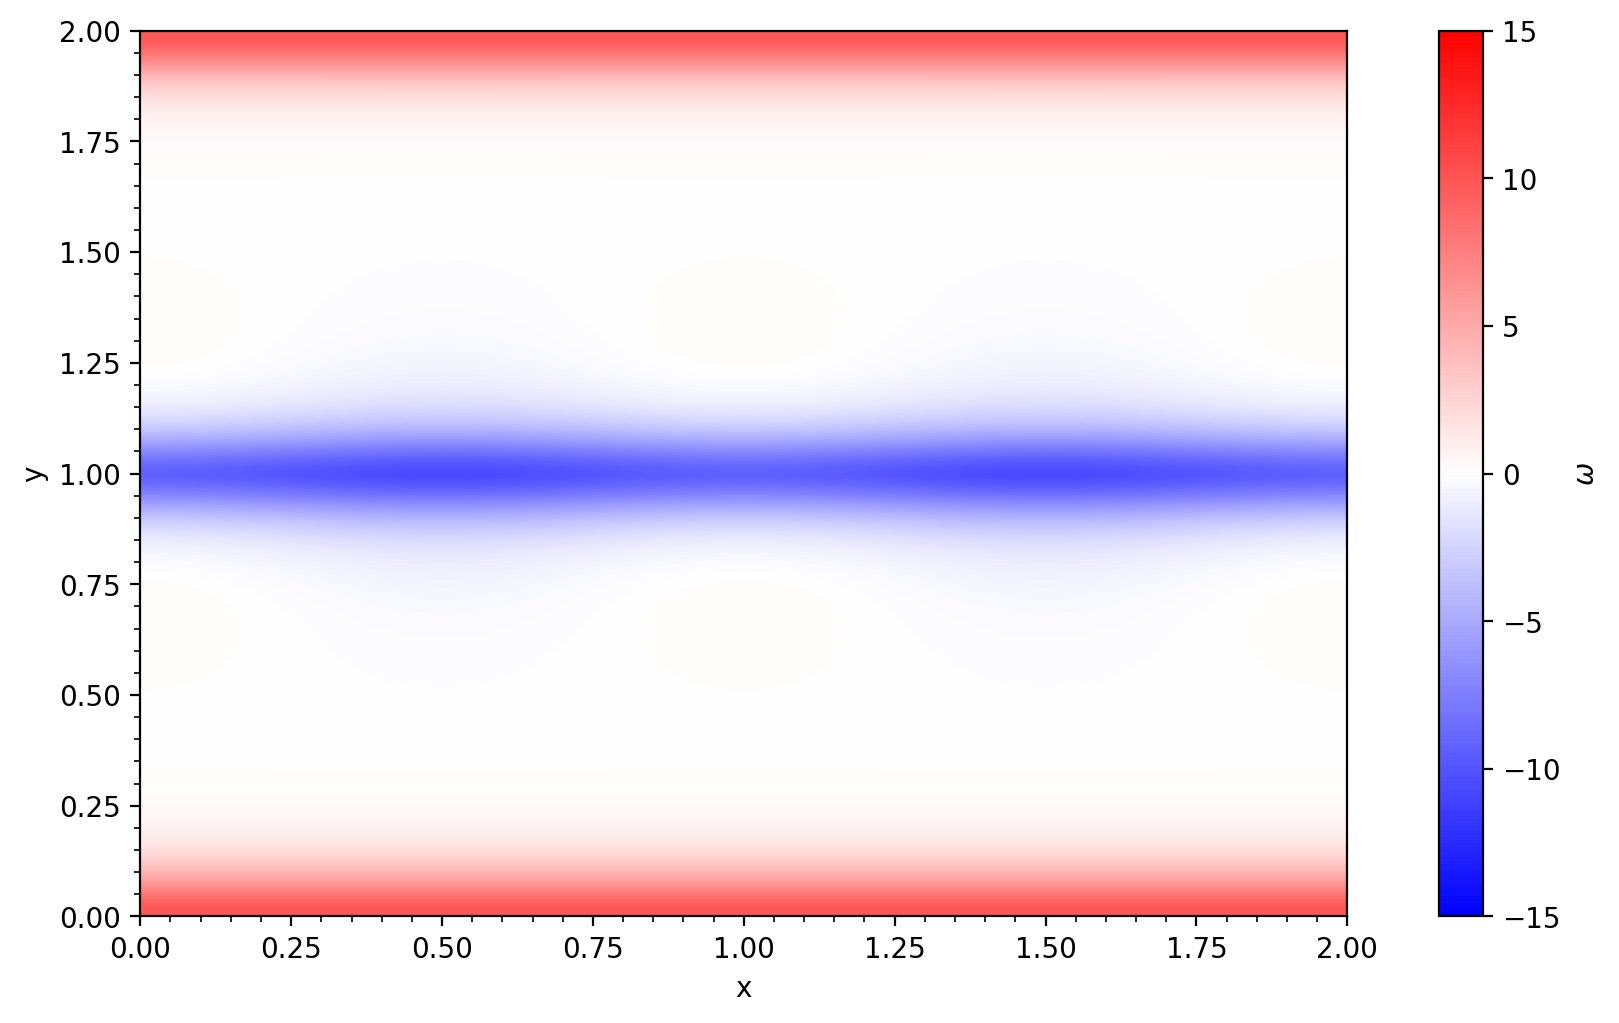

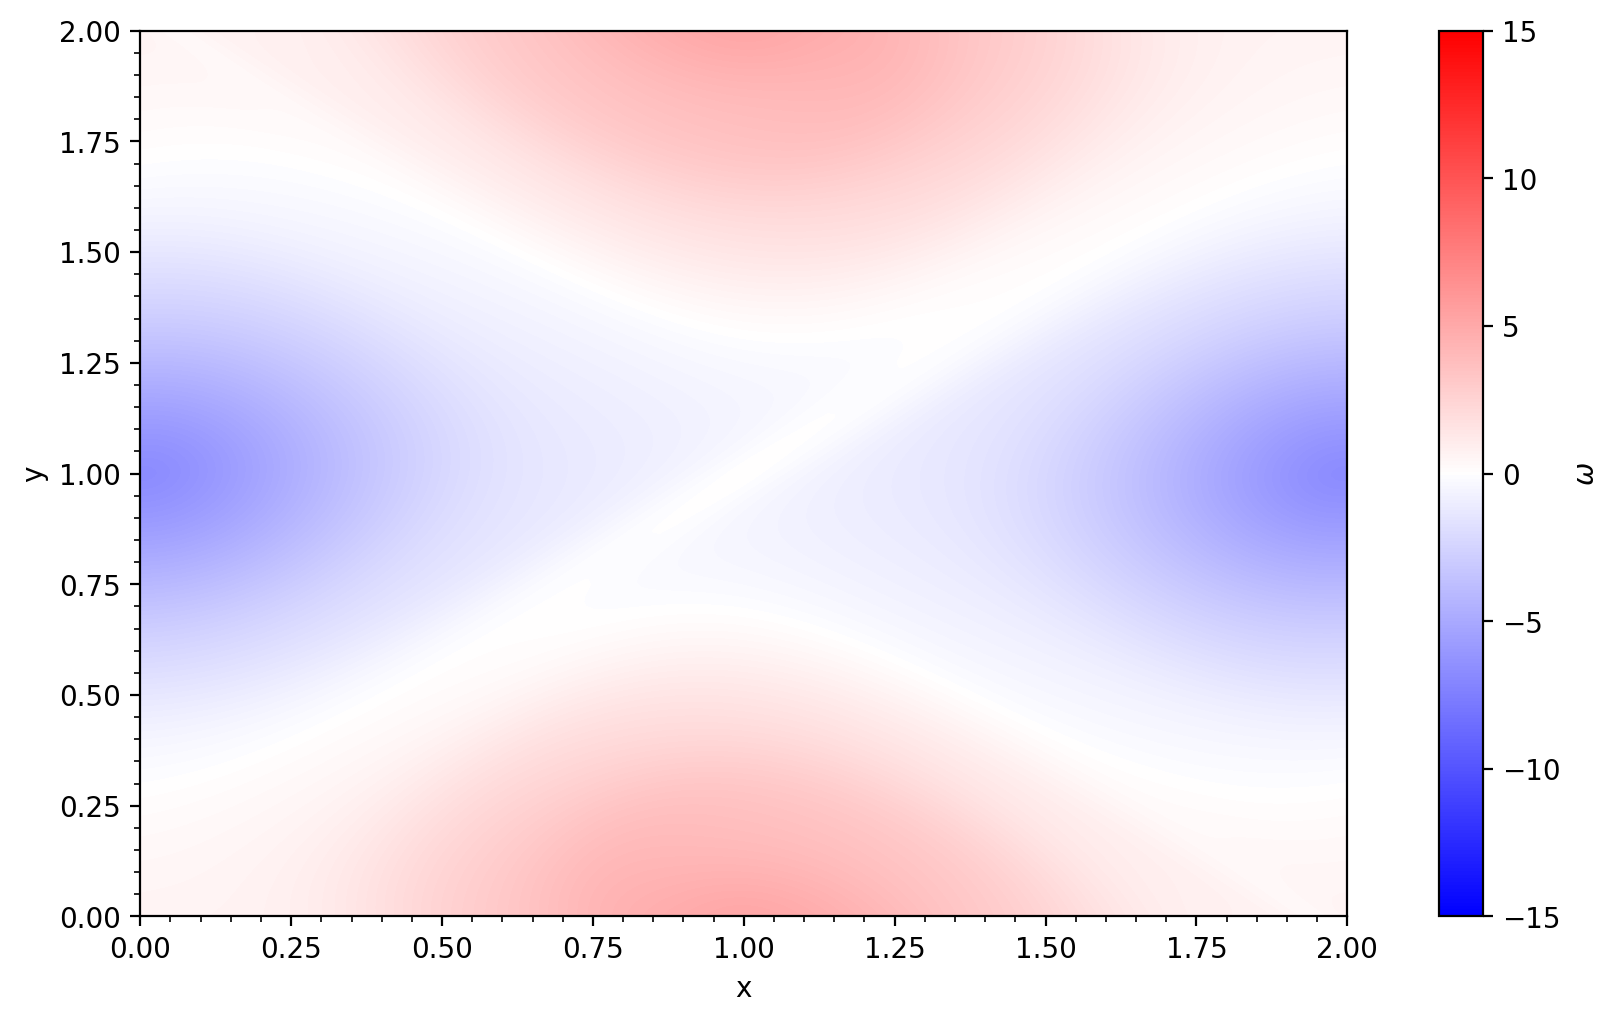

In [70]:
# Setup

def build_block(rho, dt, dx, dy, u, v):
    b = np.zeros_like(u)
    b[1:-1, 1:-1] = (rho * (1 / dt * ((u[1:-1, 2:] - u[1:-1, 0:-2]) / (2 * dx) +
                                      (v[2:, 1:-1] - v[0:-2, 1:-1]) / (2 * dy)) -
                            ((u[1:-1, 2:] - u[1:-1, 0:-2]) / (2 * dx))**2 -
                            2 * ((u[2:, 1:-1] - u[0:-2, 1:-1]) / (2 * dy) *
                                 (v[1:-1, 2:] - v[1:-1, 0:-2]) / (2 * dx))-
                            ((v[2:, 1:-1] - v[0:-2, 1:-1]) / (2 * dy))**2))
    
    b[1:-1, -1] = (rho * (1 / dt * ((u[1:-1, 0] - u[1:-1,-2]) / (2 * dx) +
                                    (v[2:, -1] - v[0:-2, -1]) / (2 * dy)) -
                          ((u[1:-1, 0] - u[1:-1, -2]) / (2 * dx))**2 -
                          2 * ((u[2:, -1] - u[0:-2, -1]) / (2 * dy) *
                               (v[1:-1, 0] - v[1:-1, -2]) / (2 * dx)) -
                          ((v[2:, -1] - v[0:-2, -1]) / (2 * dy))**2))

    b[1:-1, 0] = (rho * (1 / dt * ((u[1:-1, 1] - u[1:-1, -1]) / (2 * dx) +
                                   (v[2:, 0] - v[0:-2, 0]) / (2 * dy)) -
                         ((u[1:-1, 1] - u[1:-1, -1]) / (2 * dx))**2 -
                         2 * ((u[2:, 0] - u[0:-2, 0]) / (2 * dy) *
                              (v[1:-1, 1] - v[1:-1, -1]) / (2 * dx))-
                         ((v[2:, 0] - v[0:-2, 0]) / (2 * dy))**2))
    
    return b

def pressure_poisson(p, dx, dy):
    pn = np.empty_like(p)
    
    for q in range(nit):
        pn = p.copy()
        p[1:-1, 1:-1] = (((pn[1:-1, 2:] + pn[1:-1, 0:-2]) * dy**2 +
                          (pn[2:, 1:-1] + pn[0:-2, 1:-1]) * dx**2) /
                         (2 * (dx**2 + dy**2)) -
                         dx**2 * dy**2 / (2 * (dx**2 + dy**2)) * b[1:-1, 1:-1])

        # Periodic Pressure Boundary (Crucial to stop blobs)
        p[1:-1, 0] = p[1:-1, -2]
        p[1:-1, -1] = p[1:-1, 1]
        
        p[0, :]  = p[-2, :]
        p[-1, :] = p[1, :]
    
    return p

nx = 201
ny = 211
nt = 21000
nit = 100
dx = 2 / (nx - 1)
dy = 2.1 / (ny - 1)
x = np.linspace(0, 2, nx)
y = np.linspace(-0.05, 2.05, ny)
X, Y = np.meshgrid(x, y)

rho = 1
nu = .0001

dt = .0005

u = np.zeros((ny, nx))
un = np.zeros((ny, nx))

v = np.zeros((ny, nx))
vn = np.zeros((ny, nx))

p = np.ones((ny, nx))
pn = np.ones((ny, nx))

b = np.zeros((ny, nx))

u = - np.tanh((Y - 0.0) / 0.1) + np.tanh((Y - 1.0) / 0.1) - np.tanh((Y - 2.0) / 0.1)
v = 0.1 * np.sin(2 * np.pi * X / 1.0) * np.exp(-(Y - 1.0)**2 / 0.1)

w = (np.gradient(v, axis=1) / dx) - (np.gradient(u, axis=0) / dy)

# Initial

cnt = plt.contourf(X, Y, w, levels=np.linspace(-15, 15, 256), cmap='bwr')
cnt.set_edgecolor('face')
cb = plt.colorbar(cnt, ticks=np.linspace(-15, 15, 7), location='right')
cb.set_label(r'$\omega$')
plt.xlabel('x')
plt.ylabel('y')
plt.xlim(0, 2)
plt.ylim(0, 2)
plt.show()
plt.close()

# Evolution

k = 100

history = [w.copy()]

for n in range(nt):
    un = u.copy()
    vn = v.copy()

    b = build_block(rho, dt, dx, dy, u, v)
    p = pressure_poisson(p, dx, dy)

        # Calculate convective derivatives using Upwind Differencing
    u_adv = np.zeros_like(u)
    v_adv = np.zeros_like(v)
    
    # u-advection for u: u * du/dx + v * du/dy
    u_adv[1:-1, 1:-1] = (np.maximum(un[1:-1, 1:-1], 0) * (un[1:-1, 1:-1] - un[1:-1, 0:-2]) / dx +
                         np.minimum(un[1:-1, 1:-1], 0) * (un[1:-1, 2:] - un[1:-1, 1:-1]) / dx +
                         np.maximum(vn[1:-1, 1:-1], 0) * (un[1:-1, 1:-1] - un[0:-2, 1:-1]) / dy +
                         np.minimum(vn[1:-1, 1:-1], 0) * (un[2:, 1:-1] - un[1:-1, 1:-1]) / dy)
    
    # v-advection for v: u * dv/dx + v * dv/dy
    v_adv[1:-1, 1:-1] = (np.maximum(un[1:-1, 1:-1], 0) * (vn[1:-1, 1:-1] - vn[1:-1, 0:-2]) / dx +
                         np.minimum(un[1:-1, 1:-1], 0) * (vn[1:-1, 2:] - vn[1:-1, 1:-1]) / dx +
                         np.maximum(vn[1:-1, 1:-1], 0) * (vn[1:-1, 1:-1] - vn[0:-2, 1:-1]) / dy +
                         np.minimum(vn[1:-1, 1:-1], 0) * (vn[2:, 1:-1] - vn[1:-1, 1:-1]) / dy)

    # Now update u and v using these stable terms
    u[1:-1, 1:-1] = (un[1:-1, 1:-1] - dt * u_adv[1:-1, 1:-1] -
                     dt / (2 * rho * dx) * (p[1:-1, 2:] - p[1:-1, 0:-2]) +
                     nu * dt * ((un[1:-1, 2:] - 2*un[1:-1, 1:-1] + un[1:-1, 0:-2])/dx**2 +
                                (un[2:, 1:-1] - 2*un[1:-1, 1:-1] + un[0:-2, 1:-1])/dy**2))

    v[1:-1, 1:-1] = (vn[1:-1, 1:-1] - dt * v_adv[1:-1, 1:-1] -
                     dt / (2 * rho * dy) * (p[2:, 1:-1] - p[0:-2, 1:-1]) +
                     nu * dt * ((vn[1:-1, 2:] - 2*vn[1:-1, 1:-1] + vn[1:-1, 0:-2])/dx**2 +
                                (vn[2:, 1:-1] - 2*vn[1:-1, 1:-1] + vn[0:-2, 1:-1])/dy**2))

    u[1:-1, 0]  = u[1:-1, -2]
    u[1:-1, -1] = u[1:-1, 1]
    v[1:-1, 0]  = v[1:-1, -2]
    v[1:-1, -1] = v[1:-1, 1]

    # No-slip/Wall Boundary Conditions (Top/Bottom)
    u[0, :]  = u[-2, :]
    u[-1, :] = u[1, :]
    v[0, :]  = v[-2, :]
    v[-1, :] = v[1, :]

    if n % k == 0:
        history.append((np.gradient(v, axis=1) / dx) - (np.gradient(u, axis=0) / dy))

w = (np.gradient(v, axis=1) / dx) - (np.gradient(u, axis=0) / dy)

# Final

cnt = plt.contourf(X, Y, w, levels=np.linspace(-15, 15, 256), cmap='bwr')
cnt.set_edgecolor('face')
cb = plt.colorbar(cnt, ticks=np.linspace(-15, 15, 7), location='right')
cb.set_label(r'$\omega$')
plt.xlabel('x')
plt.ylabel('y')
plt.xlim(0, 2)
plt.ylim(0, 2)
plt.show()
plt.close()

# Animation

pause_number = 20
padded_history = ([history[0]] * pause_number) + history + ([history[-1]] * pause_number)

fig, ax = plt.subplots(dpi=150)
cnt = plt.contourf(X, Y, history[0], levels=np.linspace(-15, 15, 256), cmap='bwr', zorder=1)
cnt.set_edgecolor('face')
cb = plt.colorbar(cnt, ticks=np.linspace(-15, 15, 7), location='right')
cb.set_label(r'$\omega$')
plt.xlabel(r'$x$')
plt.ylabel(r'$y$')
plt.xlim(0, 2)
plt.ylim(0, 2)

def update(frame):
    global cnt, qvr

    if cnt is not None:
        cnt.remove()

    cnt = ax.contourf(X, Y, padded_history[frame], levels=np.linspace(-15, 15, 256), cmap='bwr', zorder=1)
    
    return cnt

ani = FuncAnimation(fig, update, frames=len(padded_history), interval=50, blit=False)

ani.save("2d_nav_stok_kelv_helm_instab.gif", writer=PillowWriter(fps=20))

plt.close()
HTML('<img src="2d_nav_stok_kelv_helm_instab.gif" width="800">')

In [67]:
# Animation

pause_number = 20
padded_history = ([history[0]] * pause_number) + history + ([history[-1]] * pause_number)

fig, ax = plt.subplots(dpi=150)
cnt = plt.contourf(X, Y, history[0], levels=np.linspace(-15, 15, 256), cmap='bwr', zorder=1)
cnt.set_edgecolor('face')
cb = plt.colorbar(cnt, ticks=np.linspace(-15, 15, 7), location='right')
cb.set_label(r'$p$')
plt.xlabel(r'$x$')
plt.ylabel(r'$y$')
plt.xlim(0, 2)
plt.ylim(0, 2)

def update(frame):
    global cnt, qvr

    if cnt is not None:
        cnt.remove()

    cnt = ax.contourf(X, Y, padded_history[frame], levels=np.linspace(-15, 15, 256), cmap='bwr', zorder=1)
    
    return cnt

ani = FuncAnimation(fig, update, frames=len(padded_history), interval=50, blit=False)

ani.save("2d_nav_stok_kelv_helm_instab.gif", writer=PillowWriter(fps=20))

plt.close()
HTML('<img src="2d_nav_stok_kelv_helm_instab.gif" width="800">')